# Mapping the World: Clustering Countries for Smarter Tourism Insights

## Project Scope and Data Sources

The goal of this project is to cluster countries based on various travel-related industry indexes, such as hospitality and historical travel data. To achieve this, we collected data from multiple sources, ensuring a comprehensive and relevant dataset.

1. **Kaggle Tourism Dataset**  
   We sourced a portion of the data from Kaggle’s [Tourism dataset](https://www.kaggle.com/datasets/imtkaggleteam/tourism?select=26-+international-arrivals-for-personal-vs-business-and-professional-reasons.csv), which includes detailed country-level information on tourism-related metrics. The data we used focuses on key factors such as:
   - Tourist accommodation
   - Food and beverage industries
   - Economic indicators related to tourism (e.g., international arrivals and tourism expenditures)

2. **Numbeo Dataset**  
   The other half of the dataset was obtained from [Numbeo](https://www.numbeo.com/), the world’s largest cost-of-living database. According to their description, Numbeo is a crowdsourced global resource for various quality of life data, covering areas such as:
   - Cost of living
   - Housing price indicators
   - Crime rates
   - Healthcare quality
   - Transport quality  
   
   We focused on the data that was specifically related to individual countries.

By combining these two sources, we aim to create a robust framework for clustering countries based on their tourism and living quality indicators.


## Creating the final Dataset

### Creating the Final Dataset

To create the final dataset, we curated data from each source and selected only the relevant information.

1. **Numbeo Data**  
   For the data from Numbeo, we performed web scraping, which is allowed under their [usage policy](https://www.numbeo.com/). This step was necessary to collect country-specific data on various quality of life indicators.

2. **Kaggle Data**  
   For the Kaggle dataset, we encountered a challenge with historical data that wasn't always the most recent or consistent in terms of the year intervals. To address this issue, we applied an **exponentially weighted average** to the yearly data. This approach allowed us to:
   - **Consolidate multiple data points** for the same country
   - **Give more weight to recent data** while still considering the historical values, ensuring that the final dataset reflects the most accurate and up-to-date information.

By following this approach, we were able to create a balanced and accurate dataset for clustering countries based on their tourism and living quality metrics.


Imports

In [1]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')


After careful consideration of each feature, we decided to drop not relevant or too similar features. 

In [2]:
# Scraped data from Numbeo database
numbeo_dataset = pd.read_csv("Data/combined_numbeo_dataset_adjusted.csv")
# Selected data from Tourism dataset on Kaggle
tourism_dataset = pd.read_csv("Data/tourism_combined_data.csv")

Merging the datasets. Because we didn't want to introduce more null data, we chose to perform an inner join even if this makes the dataset have less countries. 

In [3]:
combined_df_inner = pd.merge(tourism_dataset,numbeo_dataset, on="Country", how="inner")
combined_df_inner 

,Code,Country,tourism_employment_per_1000_over_time,food_employment_per_1000_over_time,tourism_gdp_percentage_over_time,business_to_personal_ratio_over_time,avg_stay_days_over_time,inbound_arrivals_over_time,domestic_tourists_over_time,inbound_to_outbound_ratio_over_time,...,Crime Index_crime_index,Safety Index_crime_index,Health Care Index_health_care_index,Pollution Index_pollution_index,Quality of Life Index_quality_of_life_index,Climate Index_quality_of_life_index,Traffic Index_traffic_index,Time Index(in minutes)_traffic_index,Inefficiency Index_traffic_index,CO2Emission Index_traffic_index
0,ALB,Albania,15.608840,NaN,NaN,0.021680,2.562741,1793.802738,NaN,NaN,...,44.7,55.3,48.2,77.0,104.3,86.4,114.7,36.7,105.7,1492.0
1,DZA,Algeria,7.411779,NaN,1.129921,1.764563,1.621484,NaN,NaN,NaN,...,52.6,47.4,54.5,63.9,NaN,NaN,NaN,NaN,NaN,NaN
2,AGO,Angola,2.439200,0.710283,NaN,0.111823,4.000000,2.001969,NaN,6.428571,...,66.3,33.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ARG,Argentina,28.270541,11.444930,1.890788,0.140625,2.552286,16.460292,645.361734,0.420933,...,63.4,36.6,68.0,50.8,118.0,98.3,175.4,43.8,190.9,4039.3
4,AUS,Australia,21.464763,7.825559,1.572674,0.280377,2.216665,247.324185,3157.386095,NaN,...,47.3,52.7,73.4,26.8,192.2,93.8,163.0,37.4,237.8,6245.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84,GBR,United Kingdom,42.262480,21.678139,2.069407,0.269532,2.170238,116.426500,1830.795881,NaN,...,48.3,51.7,72.7,40.7,174.5,87.2,134.2,34.7,157.4,4112.9
85,USA,United States,13.763542,3.456045,2.875489,0.160518,NaN,69.200533,NaN,0.612504,...,49.2,50.8,67.8,36.7,188.8,78.5,151.1,32.9,234.2,7302.8
86,URY,Uruguay,35.711428,14.620641,7.188250,0.084674,4.496567,913.040069,1685.925742,1.462021,...,52.0,48.0,68.6,43.5,139.8,98.0,150.7,39.5,163.3,3590.9
87,UZB,Uzbekistan,1.545283,NaN,NaN,0.021544,2.551356,NaN,NaN,NaN,...,27.9,72.1,NaN,54.0,NaN,NaN,NaN,NaN,NaN,NaN


The dataset now has data on 89 countries out of the 195 countries in the world.

In [4]:
combined_df_inner.drop(columns=["Rent Index_cost_of_living_index", "Crime Index_crime_index", "CO2Emission Index_traffic_index"], inplace=True)

combined_df_inner.columns

Index(['Code', 'Country', 'tourism_employment_per_1000_over_time',
       'food_employment_per_1000_over_time',
       'tourism_gdp_percentage_over_time',
       'business_to_personal_ratio_over_time', 'avg_stay_days_over_time',
       'inbound_arrivals_over_time', 'domestic_tourists_over_time',
       'inbound_to_outbound_ratio_over_time',
       'Cost of Living Index_cost_of_living_index',
       'Groceries Index_cost_of_living_index',
       'Restaurant Price Index_cost_of_living_index',
       'Safety Index_crime_index', 'Health Care Index_health_care_index',
       'Pollution Index_pollution_index',
       'Quality of Life Index_quality_of_life_index',
       'Climate Index_quality_of_life_index', 'Traffic Index_traffic_index',
       'Time Index(in minutes)_traffic_index',
       'Inefficiency Index_traffic_index'],
      dtype='object')

Renaming the columns using the same naming conventions.

In [5]:
rename_dict = {
    'Code': 'CountryCode',
    'Country': 'CountryName',
    'tourism_employment_per_1000_over_time': 'TourismEmploymentPer1000',
    'food_employment_per_1000_over_time': 'FoodEmploymentPer1000',
    'tourism_gdp_percentage_over_time': 'TourismGDPPercentage',
    'business_to_personal_ratio_over_time': 'BusinessToPersonalRatio',
    'avg_stay_days_over_time': 'AverageStayDays',
    'inbound_arrivals_over_time': 'InboundArrivalsPer1000',
    'domestic_tourists_over_time': 'DomesticTouristsPer1000',
    'inbound_to_outbound_ratio_over_time': 'InboundToOutboundRatio',
    'Cost of Living Index_cost_of_living_index': 'CostOfLivingIndex',
    'Groceries Index_cost_of_living_index': 'GroceriesCostIndex',
    'Restaurant Price Index_cost_of_living_index': 'RestaurantPriceIndex',
    'Safety Index_crime_index': 'SafetyIndex',
    'Health Care Index_health_care_index': 'HealthCareIndex',
    'Pollution Index_pollution_index': 'PollutionIndex',
    'Quality of Life Index_quality_of_life_index': 'QualityOfLifeIndex',
    'Climate Index_quality_of_life_index': 'ClimateIndex',
    'Traffic Index_traffic_index': 'TrafficIndex',
    'Time Index(in minutes)_traffic_index': 'TrafficTimeIndexMinutes',
    'Inefficiency Index_traffic_index': 'TrafficInefficiencyIndex'
}

In [6]:
combined_df_inner.rename(columns=rename_dict, inplace=True)

Because the majority of the columns have a 0 to positive integer scale, 0 being te lowest score and the positive integer being the highest, we decided to make all the other features increasing monotonic as well.

In [7]:
combined_df_inner["ReverseTrafficInefficiencyIndex"] = combined_df_inner["TrafficInefficiencyIndex"].max() - combined_df_inner["TrafficInefficiencyIndex"]
combined_df_inner["ReverseTrafficTimeIndexMinutes"] = combined_df_inner["TrafficTimeIndexMinutes"].max() - combined_df_inner["TrafficTimeIndexMinutes"]
combined_df_inner["ReverseTrafficIndex"] = combined_df_inner["TrafficIndex"].max() - combined_df_inner["TrafficIndex"]
combined_df_inner["ReversePollutionIndex"] = combined_df_inner["PollutionIndex"].max() - combined_df_inner["PollutionIndex"]

Exporting the dataset.

In [8]:
combined_df_inner.to_csv('Data/final_dataset.csv', index=False)

## Exploratory Data Analysis

Imports

In [9]:
import pandas as pd
import missingno
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

from scipy.stats import spearmanr
import numpy as np
from sklearn.preprocessing import MinMaxScaler

from tqdm import tqdm

# Suppress FutureWarnings
warnings.simplefilter(action='ignore', category=FutureWarning)
sns.set_theme(style="white")


Importing the final dataset.

In [10]:
df = pd.read_csv("Data/final_dataset.csv")

### Data Quality

Looking at the distribution of null values in the dataset.

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89 entries, 0 to 88
Data columns (total 25 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   CountryCode                      89 non-null     object 
 1   CountryName                      89 non-null     object 
 2   TourismEmploymentPer1000         89 non-null     float64
 3   FoodEmploymentPer1000            69 non-null     float64
 4   TourismGDPPercentage             69 non-null     float64
 5   BusinessToPersonalRatio          76 non-null     float64
 6   AverageStayDays                  76 non-null     float64
 7   InboundArrivalsPer1000           83 non-null     float64
 8   DomesticTouristsPer1000          58 non-null     float64
 9   InboundToOutboundRatio           60 non-null     float64
 10  CostOfLivingIndex                85 non-null     float64
 11  GroceriesCostIndex               85 non-null     float64
 12  RestaurantPriceIndex    

In [12]:
df.isnull().sum()

CountryCode                         0
CountryName                         0
TourismEmploymentPer1000            0
FoodEmploymentPer1000              20
TourismGDPPercentage               20
BusinessToPersonalRatio            13
AverageStayDays                    13
InboundArrivalsPer1000              6
DomesticTouristsPer1000            31
InboundToOutboundRatio             29
CostOfLivingIndex                   4
GroceriesCostIndex                  4
RestaurantPriceIndex                4
SafetyIndex                         1
HealthCareIndex                    23
PollutionIndex                     15
QualityOfLifeIndex                 27
ClimateIndex                       27
TrafficIndex                       26
TrafficTimeIndexMinutes            26
TrafficInefficiencyIndex           26
ReverseTrafficInefficiencyIndex    26
ReverseTrafficTimeIndexMinutes     26
ReverseTrafficIndex                26
ReversePollutionIndex              15
dtype: int64

<Axes: >

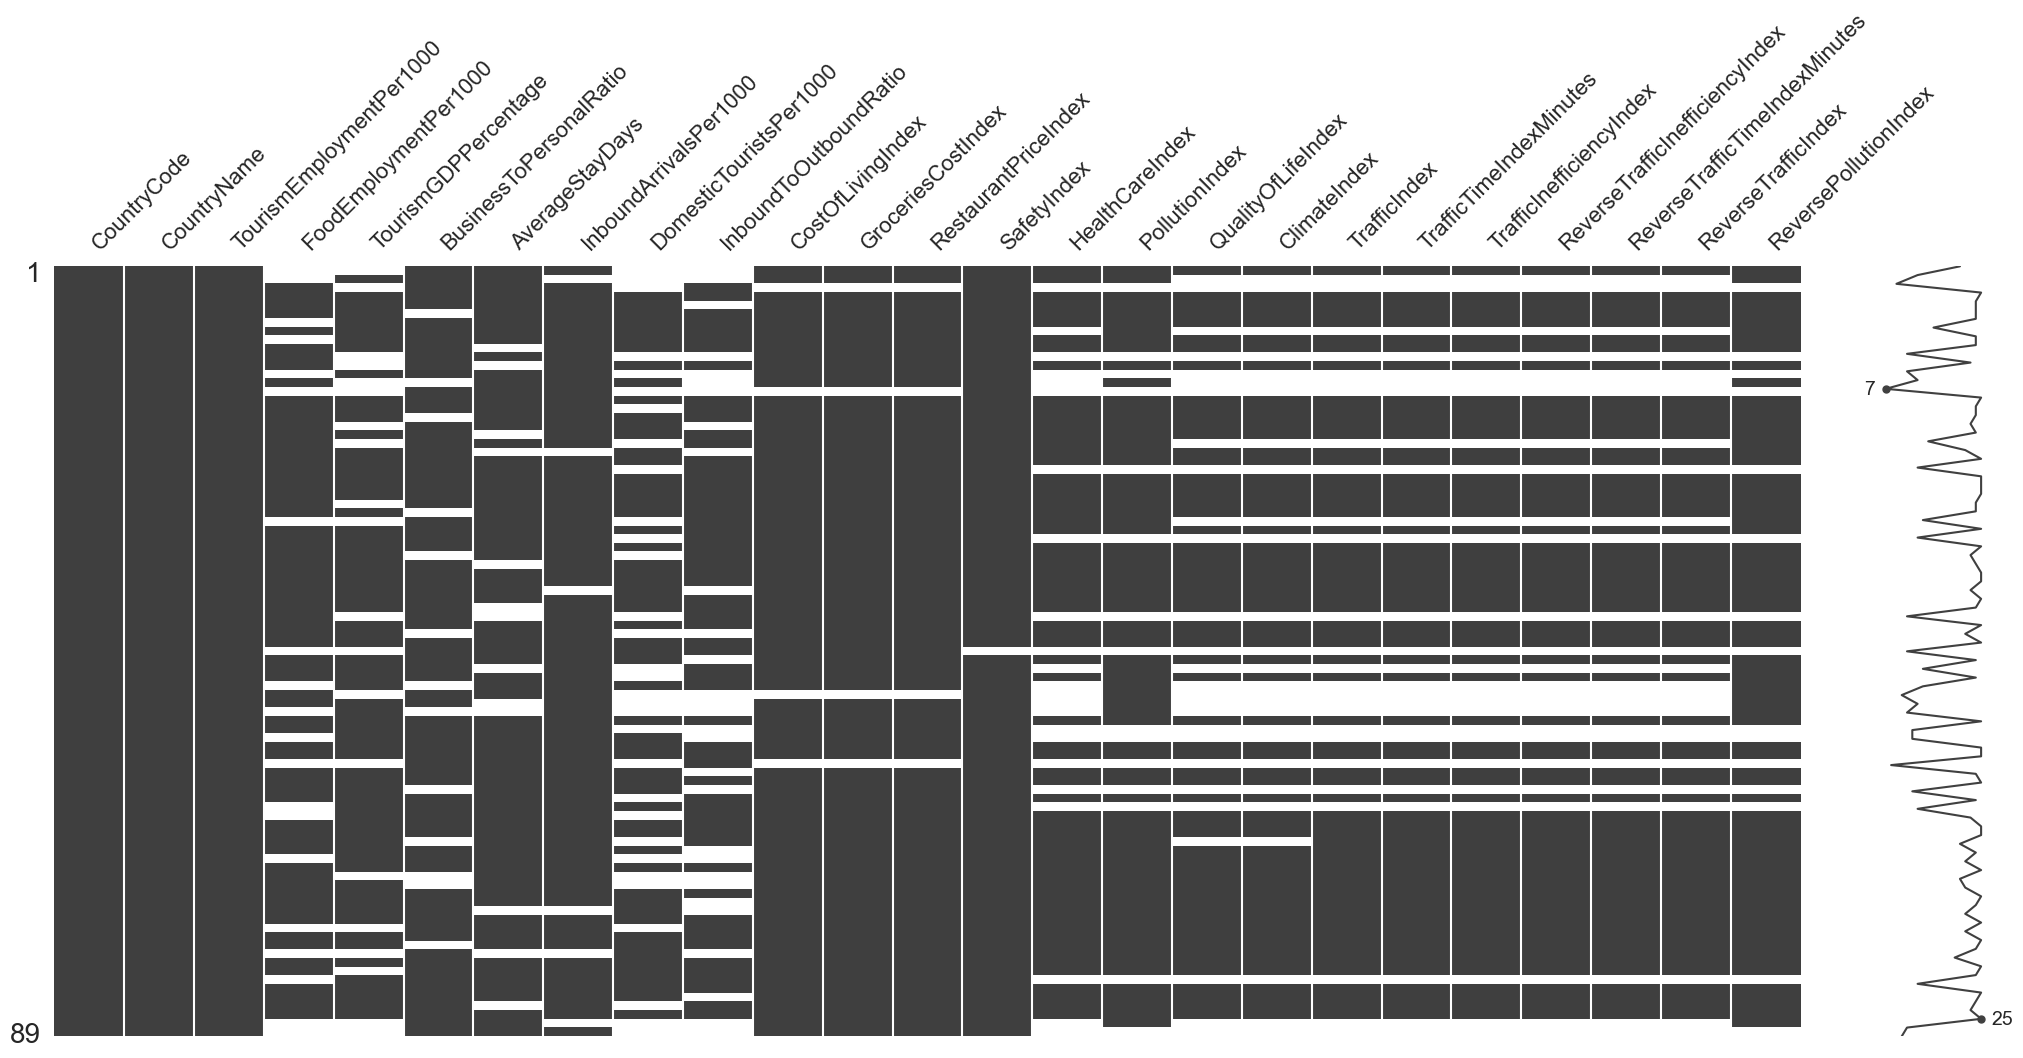

In [13]:
missingno.matrix(df)

In the worse case scenario, there are countries with as low as 7 features. The best case scenario is countries having all 25 features. 

In [14]:
df.duplicated().sum()

0

No duplicate entries found.

In [15]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
TourismEmploymentPer1000,89.0,25.639881,30.208117,0.864344,7.796310,19.709909,32.664306,197.352016
FoodEmploymentPer1000,69.0,12.246579,11.200774,0.182560,4.457795,9.858471,16.525622,54.312951
TourismGDPPercentage,69.0,3.578292,2.414450,0.061836,1.890788,3.104375,4.807650,11.728354
BusinessToPersonalRatio,76.0,0.243344,0.302023,0.009091,0.075744,0.129049,0.294344,1.764563
AverageStayDays,76.0,4.094567,3.644277,1.330224,2.027468,2.596871,4.368941,22.250457
InboundArrivalsPer1000,83.0,467.887608,810.467671,0.933245,41.244642,152.022395,579.640235,5825.335690
DomesticTouristsPer1000,58.0,1242.807826,1063.717487,0.153039,470.210368,1067.305597,1682.990724,5157.844808
InboundToOutboundRatio,60.0,2.337931,2.771569,0.197945,0.633283,1.470492,2.730327,15.654869
CostOfLivingIndex,85.0,41.295294,14.694038,19.000000,30.400000,38.800000,49.400000,98.400000
GroceriesCostIndex,85.0,43.062353,15.575301,19.700000,33.200000,40.100000,54.500000,103.100000


Features have very different scales, however by introducing the engineered "inverse"-like columns, all of them have a increasing monotone structure and meaning.

Looking at feature distribution.

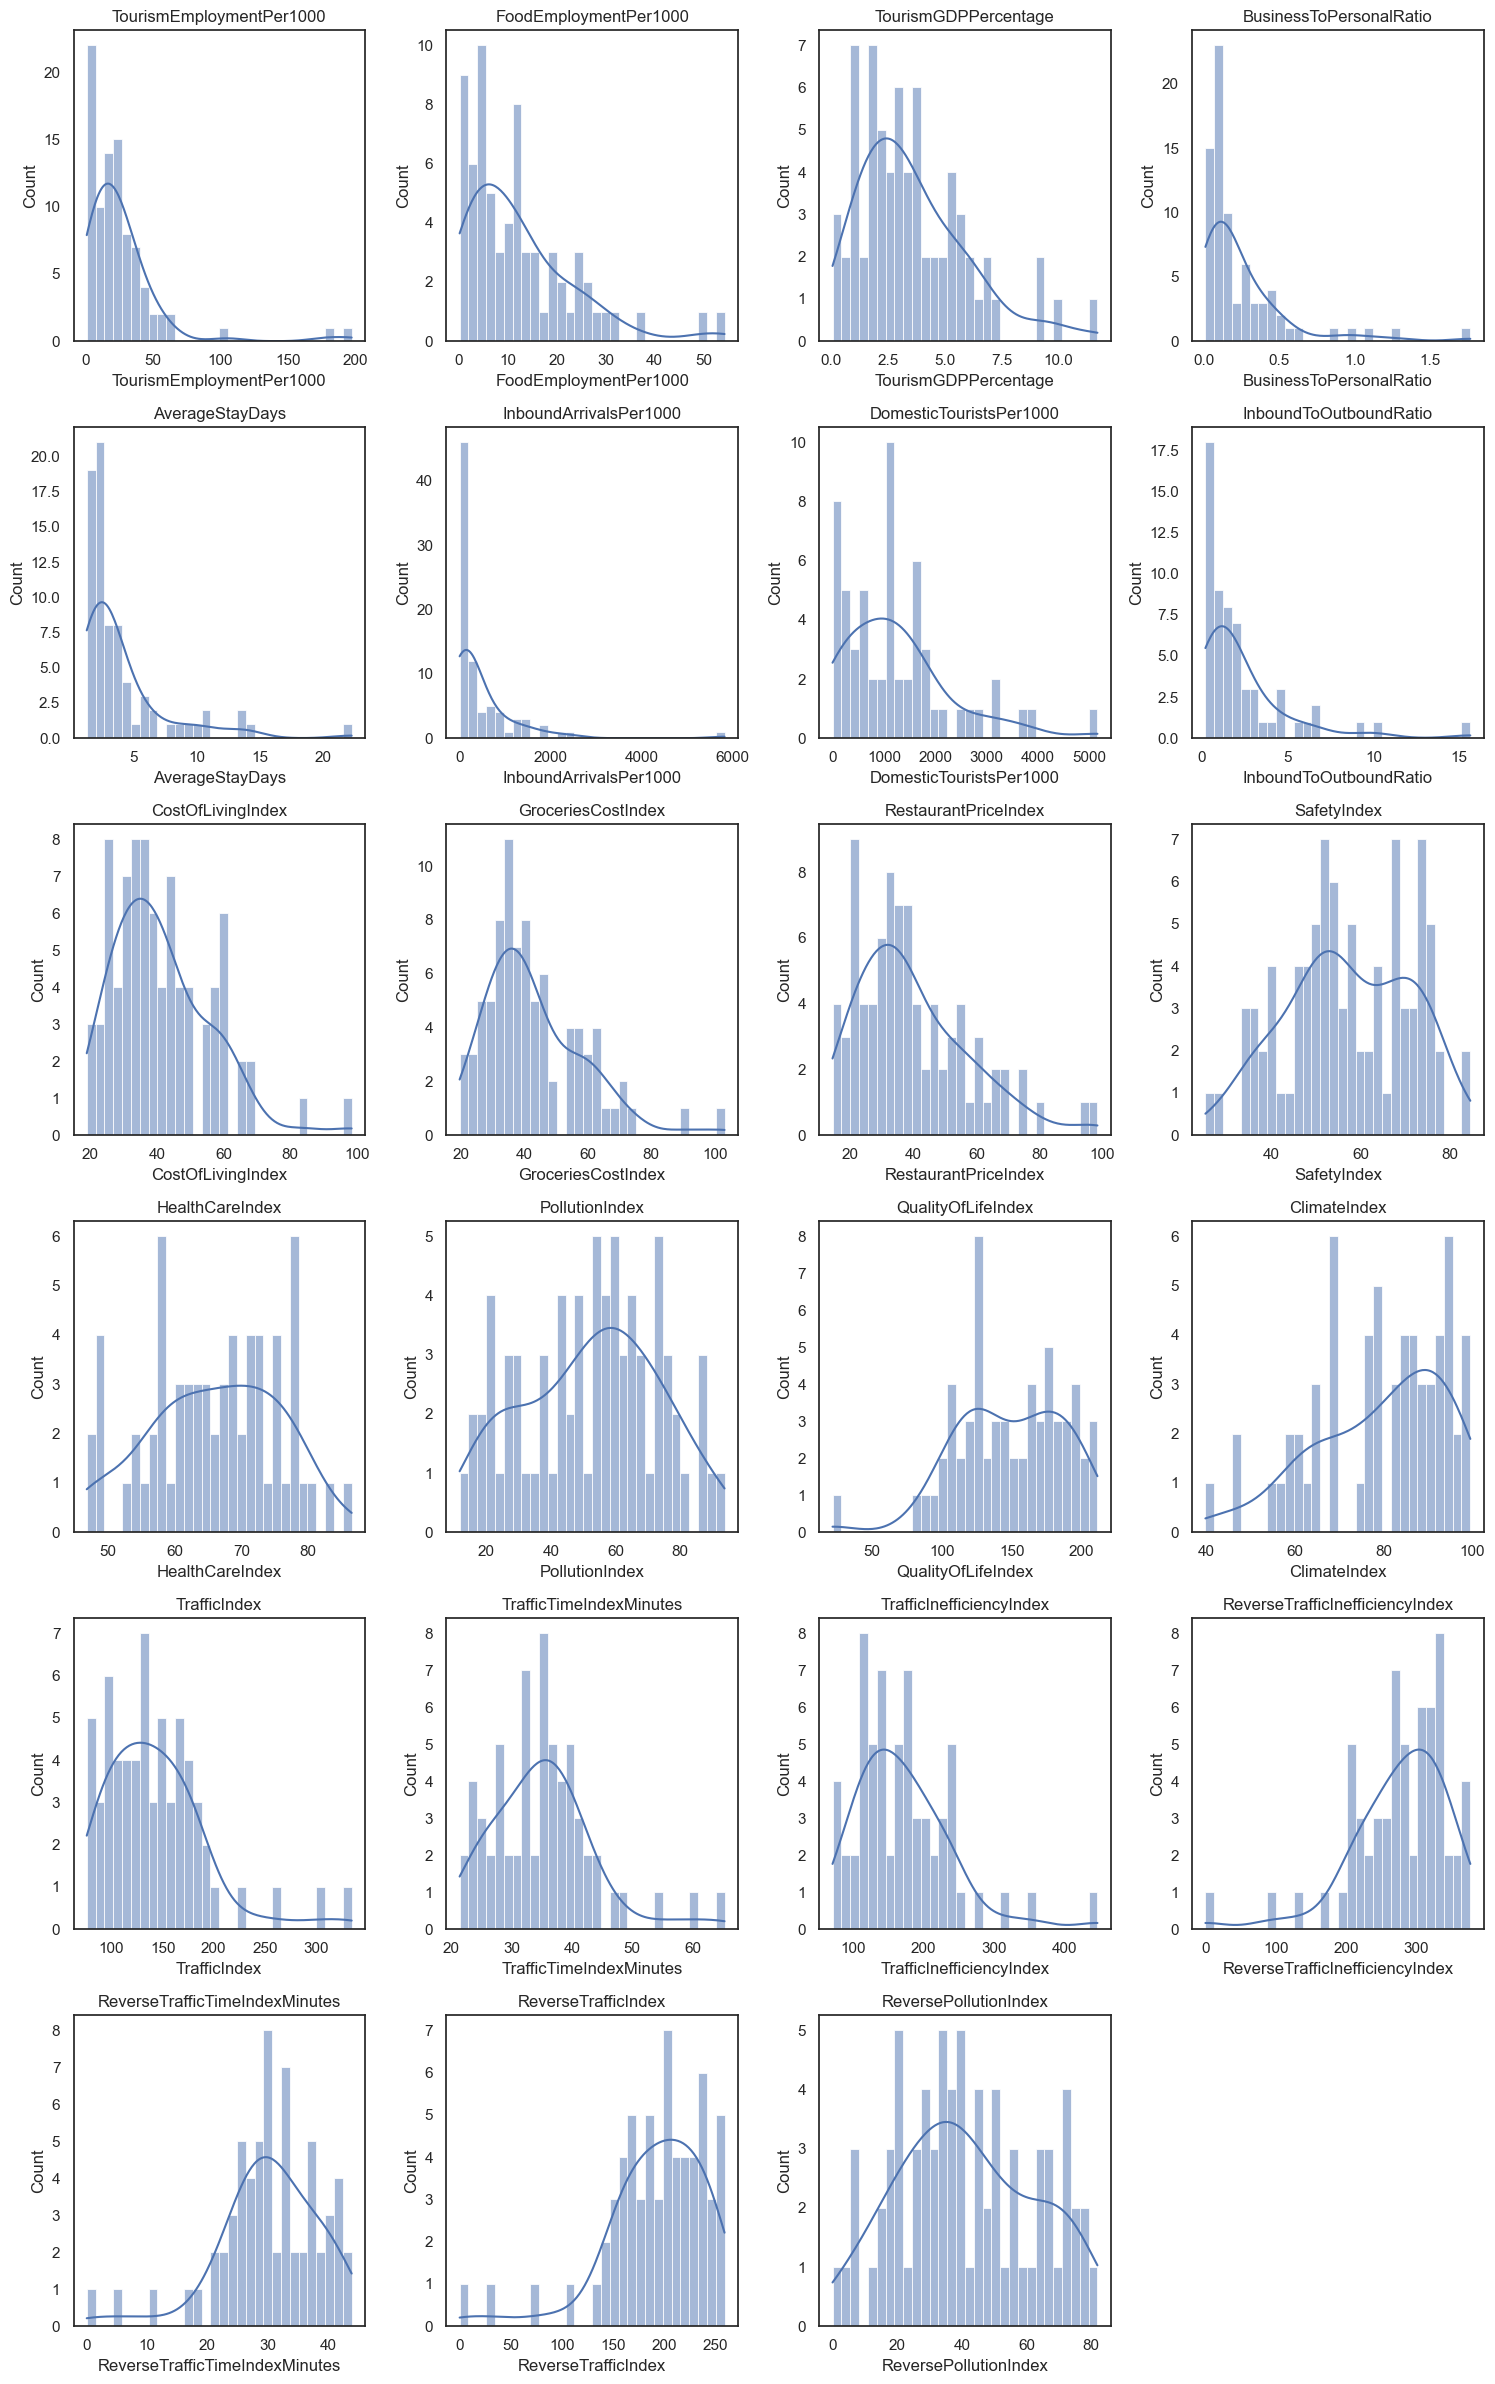

In [16]:
numerical_columns = df.select_dtypes(include=['number']).columns

# Set up the number of rows and columns for subplots
num_features = len(numerical_columns)
num_cols = 4  
num_rows = (num_features // num_cols) + (num_features % num_cols > 0)  

# Set up the figure size
plt.figure(figsize=(15, num_rows * 4))

# Loop through numerical columns and plot distributions
for i, col in enumerate(numerical_columns, 1):
    plt.subplot(num_rows, num_cols, i)
    sns.histplot(df[col].dropna(), kde=True, bins=30)
    plt.title(col)

plt.tight_layout()
plt.show()

### Comparative Analysis

#### Safety vs Healthcare

Comparing Safety Index and Healthcare Index and looking see if they are correlated.

In [17]:
# Select relevant columns and drop rows with NaN values in either column
subset = df[['CountryName', 'SafetyIndex', 'HealthCareIndex']].dropna()
print(subset.shape[0])

66


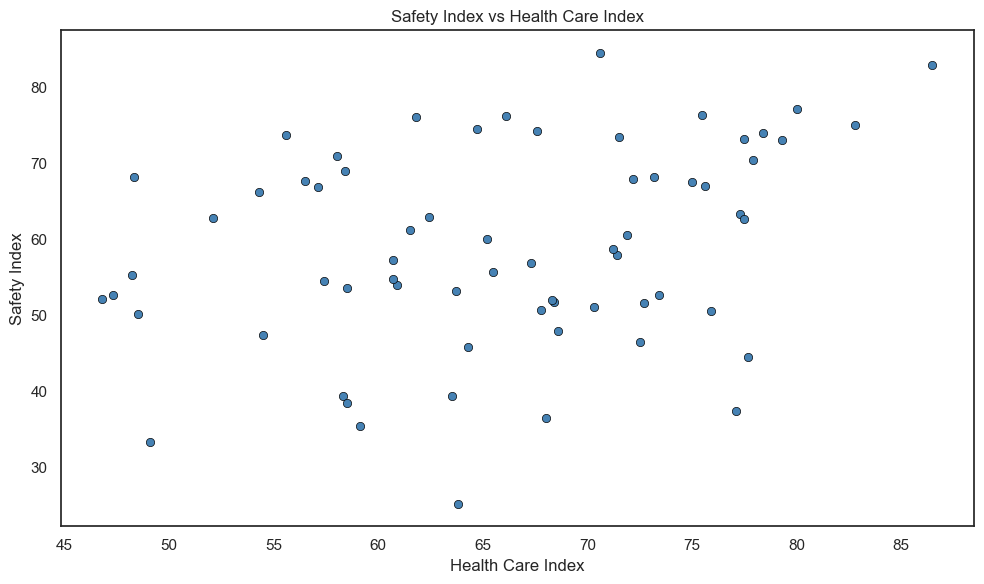

In [18]:
# Create a clearer scatter plot with uniform dot color
plt.figure(figsize=(10, 6))
scatter_plot = sns.scatterplot(
    data=subset,
    x='HealthCareIndex',
    y='SafetyIndex',
    color='steelblue',
    edgecolor='black'
)
plt.title('Safety Index vs Health Care Index')
plt.xlabel('Health Care Index')
plt.ylabel('Safety Index')
plt.tight_layout()
plt.show()

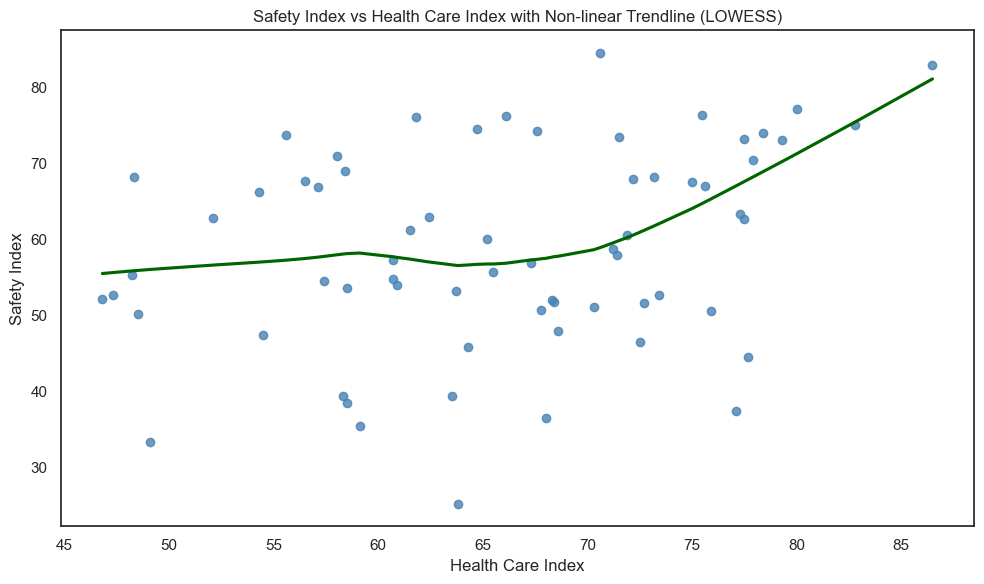

In [19]:
# Plot with non-linear trendline using lowess smoothing
plt.figure(figsize=(10, 6))
sns.set_theme(style="white")
nonlinear_plot = sns.regplot(
    data=subset,
    x='HealthCareIndex',
    y='SafetyIndex',
    scatter_kws={'color': 'steelblue'},
    line_kws={'color': 'darkgreen'},
    lowess=True
)
plt.title('Safety Index vs Health Care Index with Non-linear Trendline (LOWESS)')
plt.xlabel('Health Care Index')
plt.ylabel('Safety Index')
plt.tight_layout()
plt.show()


In [20]:
# Calculate Pearson correlation coefficient and p-value
corr_coef, p_value = spearmanr(subset['HealthCareIndex'], subset['SafetyIndex'])

# Round values
rounded_corr = round(corr_coef, 2)
rounded_p = round(p_value, 4)

# Interpret correlation strength with buffer ranges
if abs(rounded_corr) < 0.28:
    strength = "weak"
elif abs(rounded_corr) < 0.33:
    strength = "borderline weak-to-moderate"
elif abs(rounded_corr) < 0.57:
    strength = "moderate"
elif abs(rounded_corr) < 0.63:
    strength = "borderline moderate-to-strong"
else:
    strength = "strong"

# Interpret significance
if rounded_p < 0.05:
    significance = "statistically significant"
else:
    significance = "not statistically significant"

# Output
print(f"Pearson Correlation Coefficient: {rounded_corr}")
print(f"→ This indicates a {strength} positive correlation between Health Care Index and Safety Index.")

print(f"\nP-value: {rounded_p}")
print(f"→ Since it's {'below' if rounded_p < 0.05 else 'above'} 0.05, this correlation is {significance}.")

Pearson Correlation Coefficient: 0.28
→ This indicates a borderline weak-to-moderate positive correlation between Health Care Index and Safety Index.

P-value: 0.0248
→ Since it's below 0.05, this correlation is statistically significant.


In [21]:
# Rank the data
ranked_data = subset[['CountryName', 'HealthCareIndex', 'SafetyIndex']].copy()
ranked_data['HealthCareRank'] = ranked_data['HealthCareIndex'].rank(ascending=False)
ranked_data['SafetyRank'] = ranked_data['SafetyIndex'].rank(ascending=False)
ranked_data['RankDifference'] = abs(ranked_data['HealthCareRank'] - ranked_data['SafetyRank'])

# Sort by difference for clarity in plotting
ranked_data_sorted = ranked_data.sort_values(by='RankDifference', ascending=False)

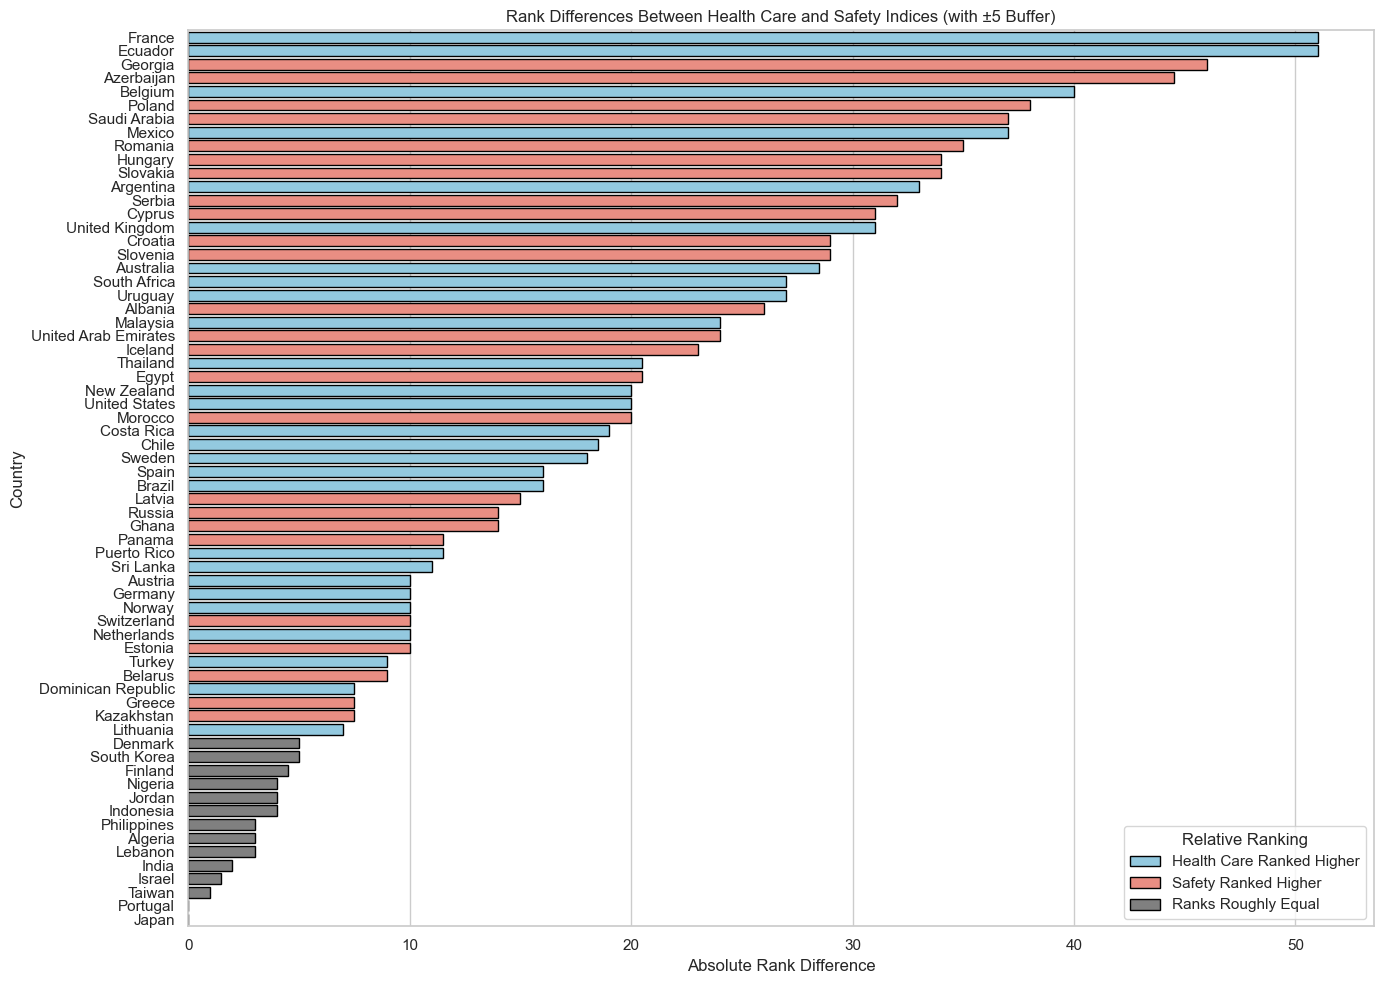

In [22]:
# Recalculate "Same Rank" using a buffer of ±5
ranked_data['HigherRankingBuffered'] = np.where(
    abs(ranked_data['HealthCareRank'] - ranked_data['SafetyRank']) <= 5,
    'Ranks Roughly Equal',
    np.where(
        ranked_data['HealthCareRank'] < ranked_data['SafetyRank'],
        'Health Care Ranked Higher',
        'Safety Ranked Higher'
    )
)

# Sort for plotting
ranked_data_sorted = ranked_data.sort_values(by='RankDifference', ascending=False)

# Plot with buffered interpretation of rank similarity
plt.figure(figsize=(14, 10))
sns.set_theme(style="whitegrid")
barplot = sns.barplot(
    data=ranked_data_sorted,
    x='RankDifference',
    y='CountryName',
    hue='HigherRankingBuffered',
    dodge=False,
    palette={
        'Health Care Ranked Higher': 'skyblue',
        'Safety Ranked Higher': 'salmon',
        'Ranks Roughly Equal': 'gray'
    },
    edgecolor='black'
)
plt.title('Rank Differences Between Health Care and Safety Indices (with ±5 Buffer)')
plt.xlabel('Absolute Rank Difference')
plt.ylabel('Country')
plt.legend(title='Relative Ranking')
plt.tight_layout()
plt.show()



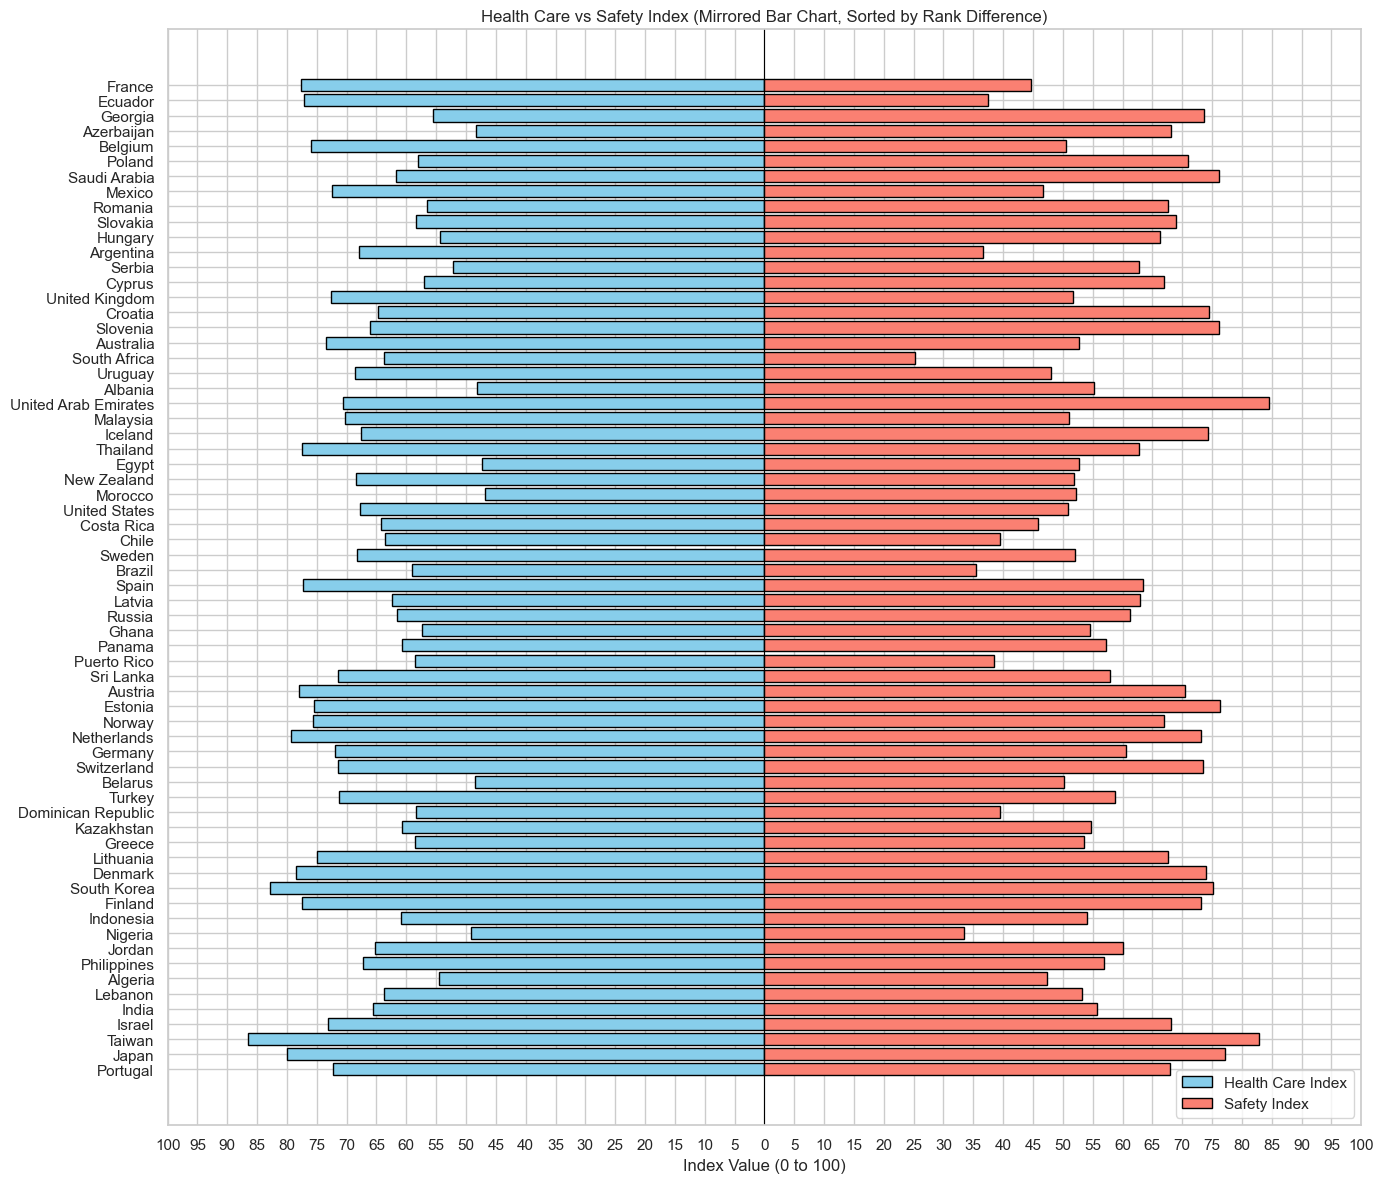

In [23]:
# Sort by the original absolute rank difference (as in the rank difference chart)
ranked_data_sorted = ranked_data.sort_values(by='RankDifference', ascending=True)

# Plot mirrored bar chart using raw index values (no normalization)
plt.figure(figsize=(14, 12))
sns.set_theme(style="whitegrid")

# Left bars (Health Care Index) as negative
plt.barh(
    ranked_data_sorted['CountryName'],
    -ranked_data_sorted['HealthCareIndex'],
    color='skyblue',
    edgecolor='black',
    label='Health Care Index'
)

# Right bars (Safety Index)
plt.barh(
    ranked_data_sorted['CountryName'],
    ranked_data_sorted['SafetyIndex'],
    color='salmon',
    edgecolor='black',
    label='Safety Index'
)

# Update tick labels to show as positive, even on the negative side
xrange =range(-100, 101, 5)
plt.xticks(
    ticks=xrange,
    labels=[str(abs(x)) for x in xrange]
)


plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Index Value (0 to 100)')
plt.title('Health Care vs Safety Index (Mirrored Bar Chart, Sorted by Rank Difference)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


#### Climate vs Quality vs Safety vs Pollution

Next, I'll create a hexbin plot to examine the relationship between climate, quality of life, and safety. Visualizing this data allows for easier detection of trends and outliers among countries.

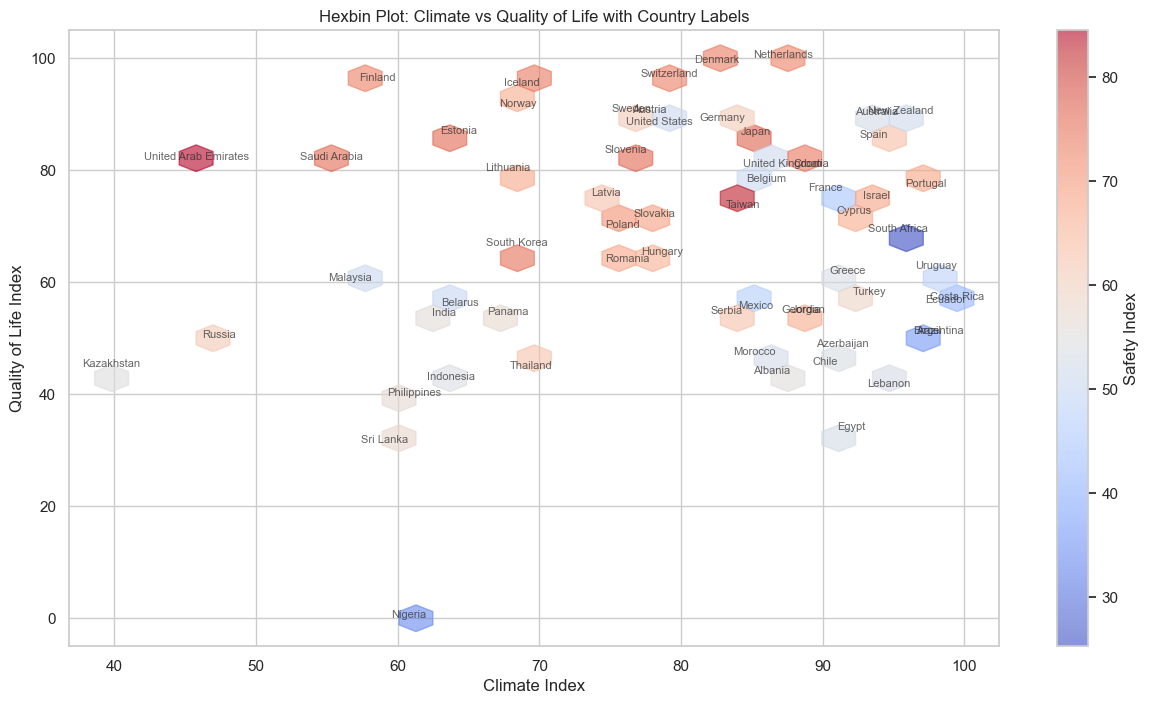

In [24]:
subset = df[['CountryName', 'ClimateIndex', 'QualityOfLifeIndex', 'SafetyIndex', 'PollutionIndex']].dropna()

scaler = MinMaxScaler(feature_range=(0, 100))
subset['QualityOfLifeIndex'] = scaler.fit_transform(subset[['QualityOfLifeIndex']])

data = subset[['CountryName','ClimateIndex','QualityOfLifeIndex', 'SafetyIndex']]


plt.figure(figsize=(15, 8))
hb = plt.hexbin(
    data['ClimateIndex'], 
    data['QualityOfLifeIndex'], 
    data['SafetyIndex'],
    gridsize=25, cmap='coolwarm', alpha=0.6
)

for i, row in data.iterrows():
    plt.text(row['ClimateIndex'], row['QualityOfLifeIndex'], row['CountryName'], fontsize=8, ha='center', alpha=0.7)

plt.colorbar(hb, label="Safety Index")
plt.xlabel("Climate Index")
plt.ylabel("Quality of Life Index")
plt.title("Hexbin Plot: Climate vs Quality of Life with Country Labels")
plt.grid(True)
plt.show()


The hexbin plot shows that countries with higher climate and quality of life scores often also have higher safety levels. Warm-colored hexagons highlight regions where safety is strongest, typically aligning with better climate and quality of life. The plot also reveals some outliers, where countries deviate from this trend. Overall, it supports the idea that good climate and quality of life often go hand-in-hand with greater safety.

Now I'm going to plot a heatmap to compare Climate Index and Quality of Life Index across countries. This visual will help identify which countries score high or low in these areas, making it easier to spot patterns, outliers, and regional trends.

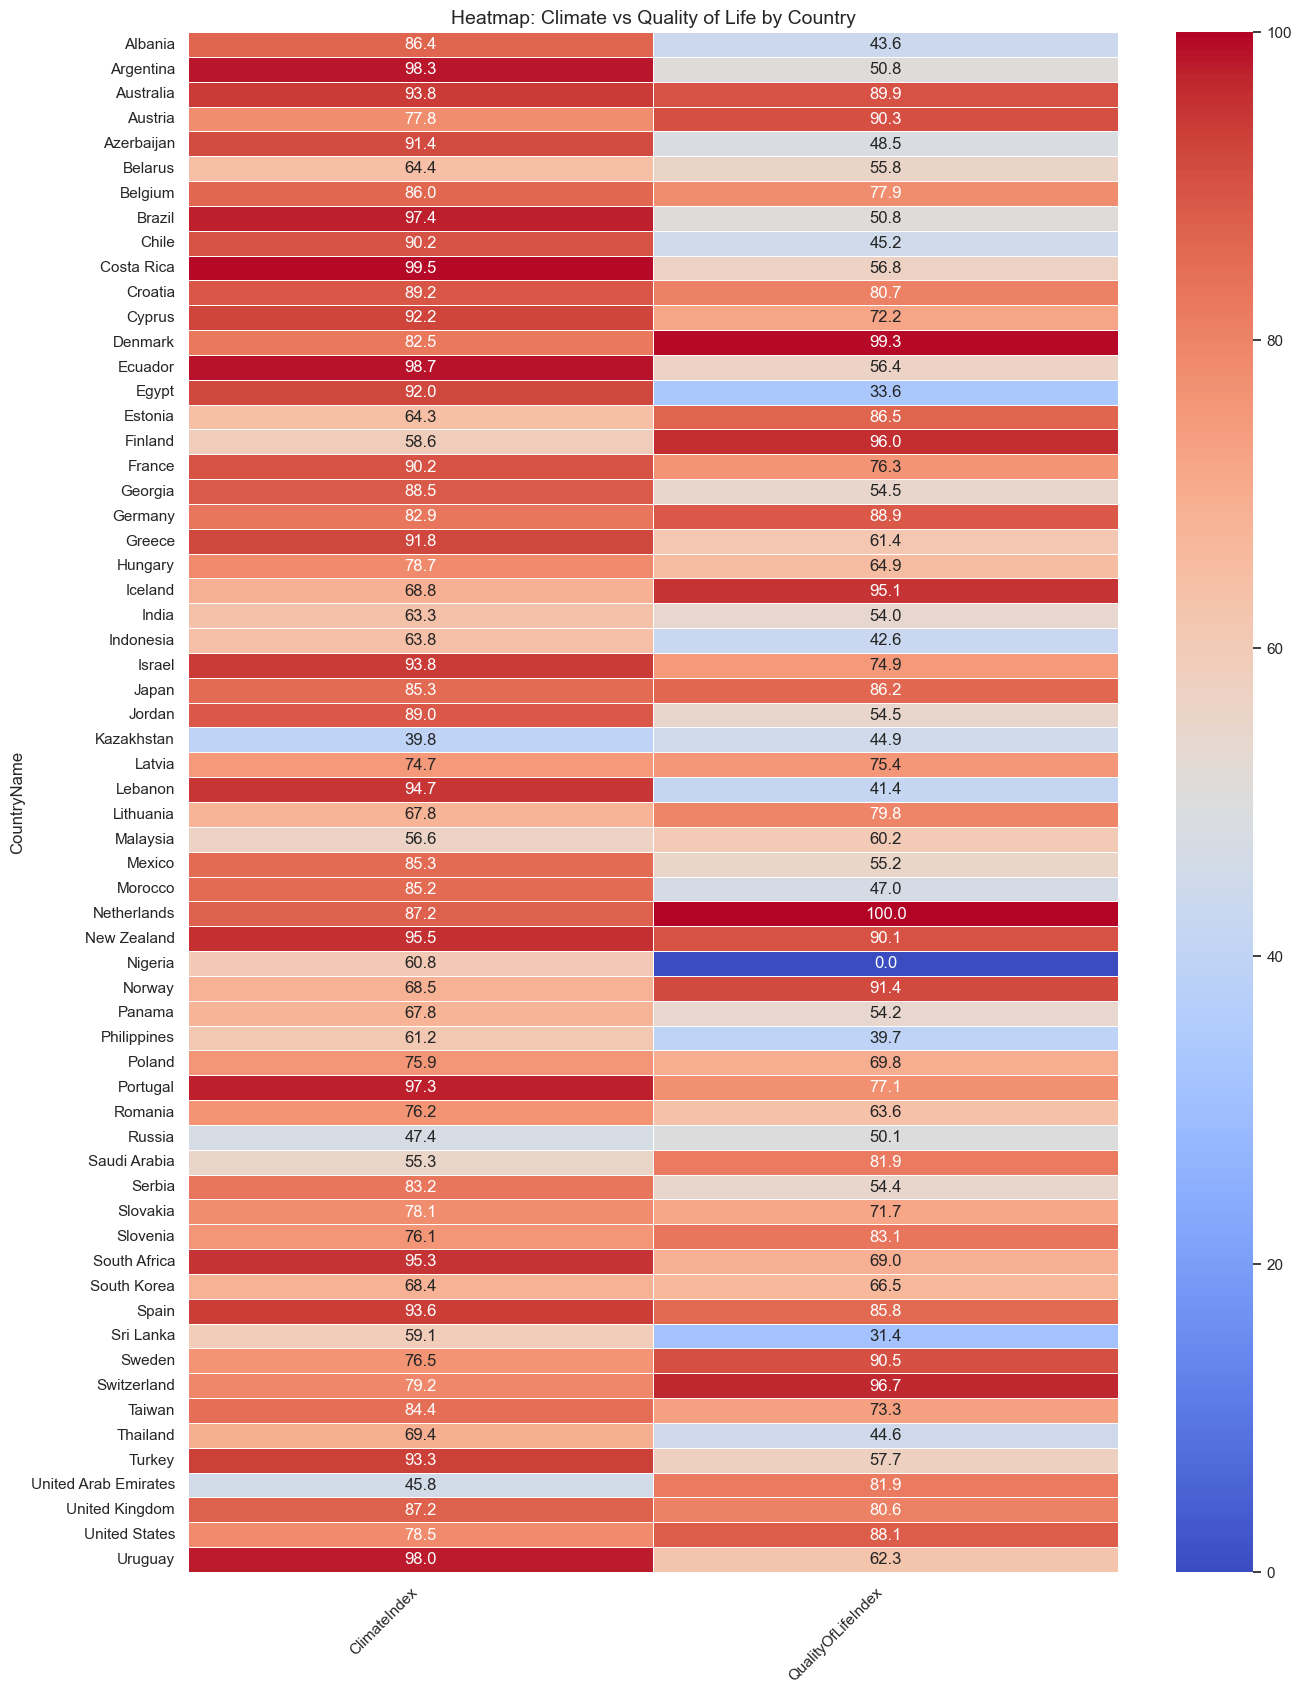

In [25]:
heatmap_data = subset[['CountryName', 'ClimateIndex', 'QualityOfLifeIndex']]

heatmap_data.set_index('CountryName', inplace=True)

plt.figure(figsize=(15, 20))
sns.heatmap(
    heatmap_data, 
    cmap="coolwarm", 
    annot=True,  
    fmt=".1f",   
    linewidths=0.5
)

plt.title("Heatmap: Climate vs Quality of Life by Country", fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.show()


The heatmap offers a clear visual comparison of the Climate Index and Quality of Life Index across different countries. By using a color gradient, it highlights where countries stand in terms of these two key indicators. Warmer colors indicate higher scores, revealing which countries enjoy both favorable climates and a high quality of life, while cooler tones point to nations with lower performance in one or both areas. The inclusion of exact values makes it easy to identify patterns, outliers, and regional differences at a glance. Overall, the heatmap effectively summarizes complex data, making it easier to interpret and compare countries based on their climate and living conditions.

Now I'm going to plot a hexbin chart to examine the relationship between climate, quality of life, and pollution across countries. This will help visualize how environmental factors like pollution interact with living conditions, and whether better climate and quality of life are consistently associated with lower pollution levels.

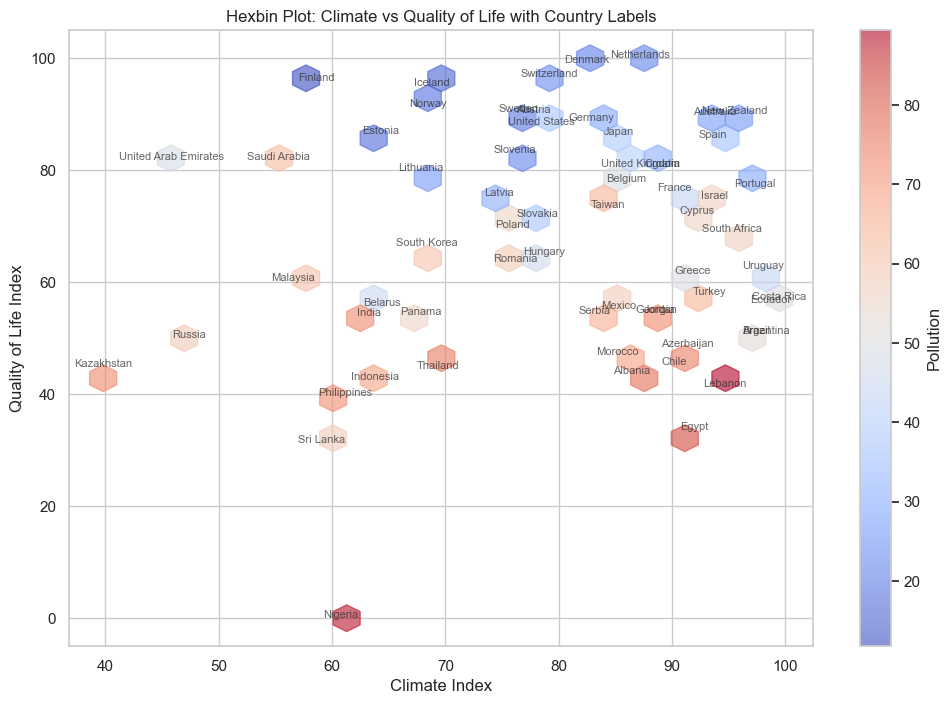

In [26]:
data = subset[['CountryName','ClimateIndex','QualityOfLifeIndex', 'PollutionIndex']]

plt.figure(figsize=(12, 8))
hb = plt.hexbin(
    data['ClimateIndex'], 
    data['QualityOfLifeIndex'], 
    data['PollutionIndex'],
    gridsize=25, cmap='coolwarm', alpha=0.6
)

for i, row in data.iterrows():
    plt.text(row['ClimateIndex'], row['QualityOfLifeIndex'], row['CountryName'], fontsize=8, ha='center', alpha=0.7)

plt.colorbar(hb, label="Pollution")
plt.xlabel("Climate Index")
plt.ylabel("Quality of Life Index")
plt.title("Hexbin Plot: Climate vs Quality of Life with Country Labels")
plt.grid(True)
plt.show()


This hexbin plot illustrates the relationship between Climate Index and Quality of Life Index, with color intensity representing the Pollution Index across countries. The visualization reveals that countries with a better climate often tend to have a higher quality of life. However, the color shading shows varying pollution levels within these clusters—some countries with high climate and quality of life scores still experience elevated pollution, while others maintain low pollution levels. This suggests that while climate and quality of life are positively related, pollution does not always follow the same trend and can vary significantly. Overall, the plot helps identify countries where favorable living conditions may be offset by environmental concerns.

#### Safety vs Average Stay

We will compare the two features safety and average stay to check if they are correlated.

In [27]:
subset = df[['CountryName', 'SafetyIndex', 'AverageStayDays']].dropna()
scaler = MinMaxScaler(feature_range = (0,100))
subset[['ScaledSafetyIndex', 'ScaledAverageStay']] = scaler.fit_transform(subset[['SafetyIndex', 'AverageStayDays']])

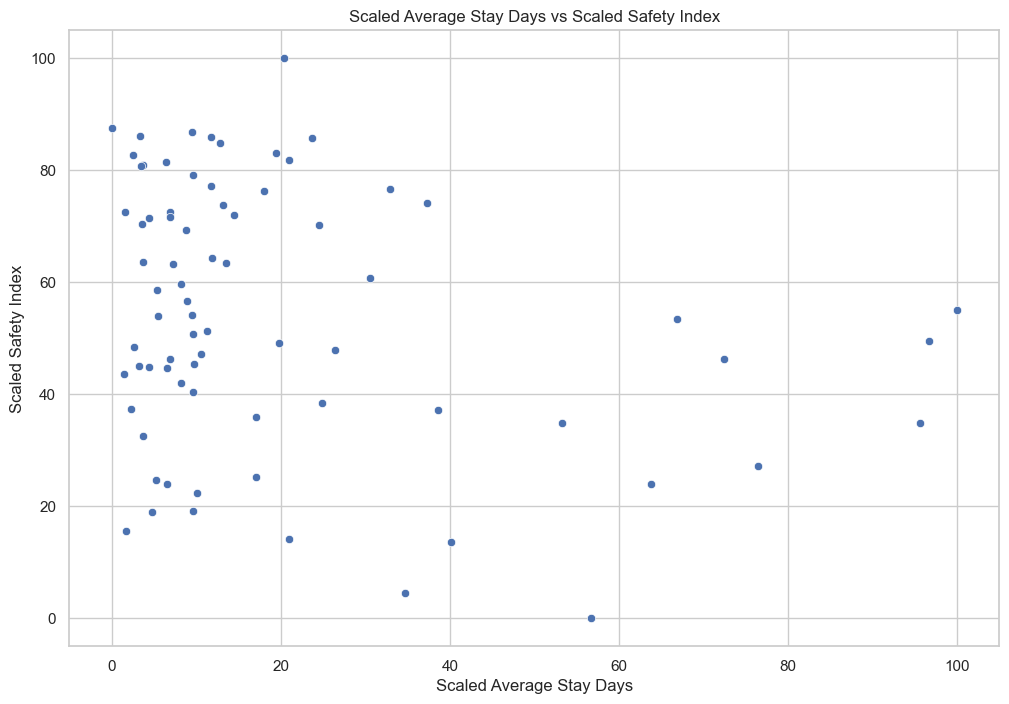

In [28]:
# %%
# Scatter plot with scaled data
plt.figure(figsize=(12, 8))

sns.scatterplot(x=subset['ScaledAverageStay'], y=subset['ScaledSafetyIndex'])
plt.title('Scaled Average Stay Days vs Scaled Safety Index')
plt.xlabel('Scaled Average Stay Days')
plt.ylabel('Scaled Safety Index')
plt.show()


The scatter plot shows the relationship between scaled average stay days and the scaled safety index. We observe that most data points cluster at lower average stay days (0-20), regardless of safety index. A few data points have higher average stay days (up to 100), and these correspond to lower safety index values. This suggests a possible inverse relationship: as the safety index decreases, average stay days tend to increase.

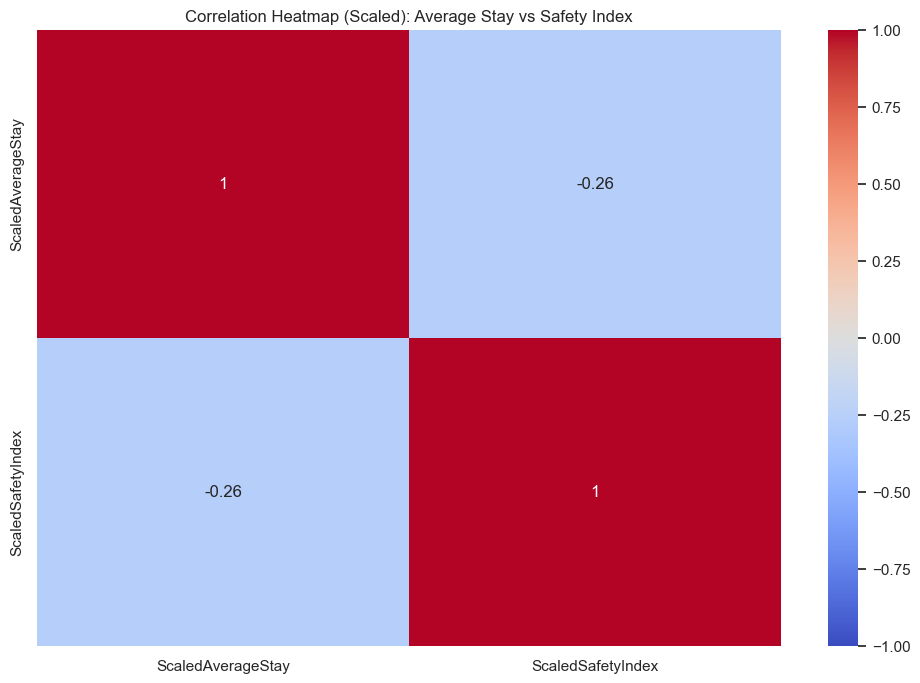

In [29]:
# %%
# Correlation heatmap (scaled)
corr = subset[['ScaledAverageStay', 'ScaledSafetyIndex']].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap (Scaled): Average Stay vs Safety Index')
plt.show()


The heatmap displays the correlation between scaled average stay days and scaled safety index. The correlation coefficient of -0.26 suggests a weak negative correlation: as the scaled safety index decreases, scaled average stay days tend to increase slightly. However, the strength of this relationship is modest, indicating that other factors may also influence the average stay days.



In [30]:
# Correlation between scaled variables
correlation = subset['ScaledAverageStay'].corr(subset['ScaledSafetyIndex'])
print('Correlation between Scaled Average Stay and Scaled Safety Index:', correlation)

Correlation between Scaled Average Stay and Scaled Safety Index: -0.258646774810228


The analysis found a weak negative correlation (-0.26) between safety and average stay duration, indicating that countries with higher safety indexes tend to have slightly shorter average stays. Visualizations confirmed this subtle inverse relationship but suggest other factors also influence stay length.

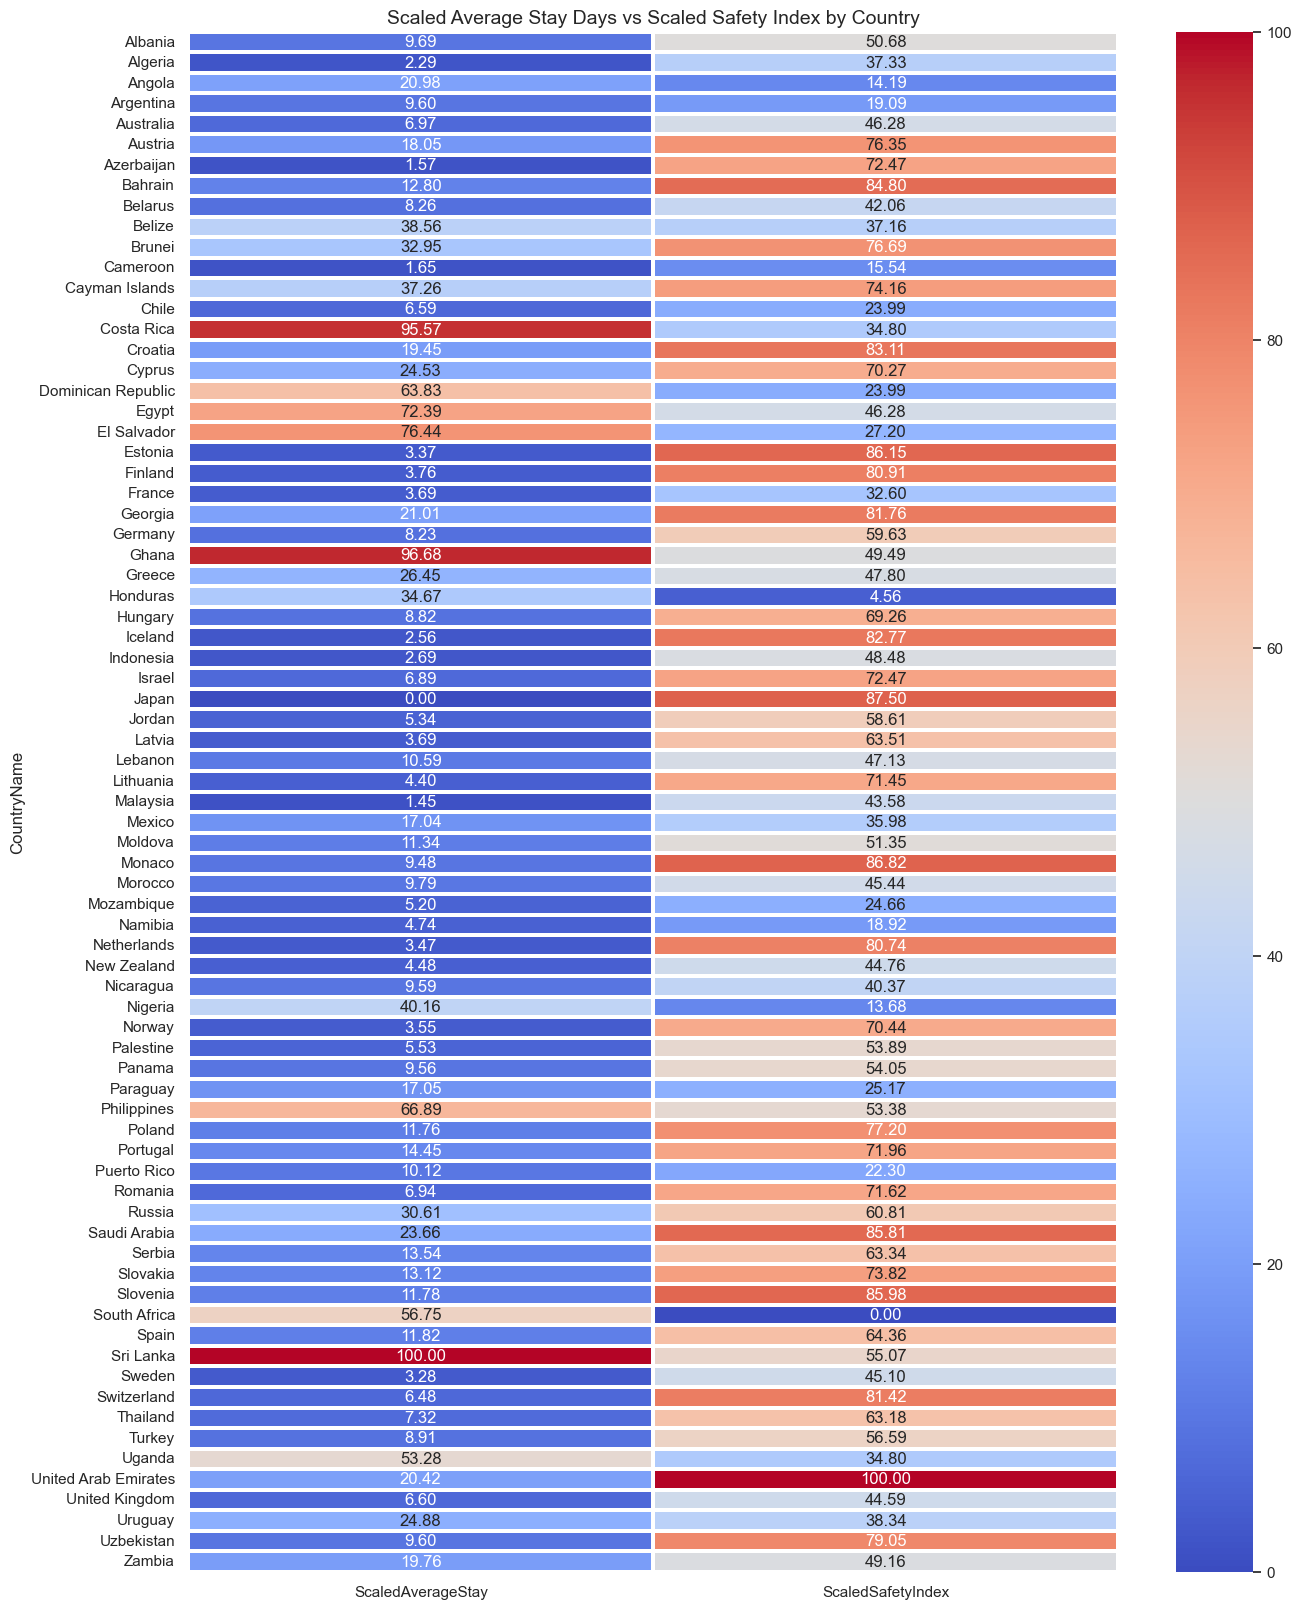

In [31]:
# %%
# Country-wise heatmap using scaled values
heatmap_data = subset[['CountryName', 'ScaledAverageStay', 'ScaledSafetyIndex']].copy()
heatmap_data.set_index('CountryName', inplace=True)

plt.figure(figsize=(15, 20))
sns.heatmap(
    heatmap_data,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    linewidths=1.5
)
plt.title("Scaled Average Stay Days vs Scaled Safety Index by Country", fontsize=14)
plt.show()


This heatmap presents scaled average stay days (left) and scaled safety index (right) for various countries. While the scaled stay days vary significantly, some countries with high average stay days (like Costa Rica, Egypt, and El Salvador) also have relatively low safety indexes, suggesting a possible inverse relationship. However, many countries do not follow this pattern, indicating the relationship might be influenced by other regional or socioeconomic factors.



## Data Preparation

In [32]:
df = pd.read_csv("Data/final_dataset.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89 entries, 0 to 88
Data columns (total 25 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   CountryCode                      89 non-null     object 
 1   CountryName                      89 non-null     object 
 2   TourismEmploymentPer1000         89 non-null     float64
 3   FoodEmploymentPer1000            69 non-null     float64
 4   TourismGDPPercentage             69 non-null     float64
 5   BusinessToPersonalRatio          76 non-null     float64
 6   AverageStayDays                  76 non-null     float64
 7   InboundArrivalsPer1000           83 non-null     float64
 8   DomesticTouristsPer1000          58 non-null     float64
 9   InboundToOutboundRatio           60 non-null     float64
 10  CostOfLivingIndex                85 non-null     float64
 11  GroceriesCostIndex               85 non-null     float64
 12  RestaurantPriceIndex    

In [33]:
df.isnull().sum()

CountryCode                         0
CountryName                         0
TourismEmploymentPer1000            0
FoodEmploymentPer1000              20
TourismGDPPercentage               20
BusinessToPersonalRatio            13
AverageStayDays                    13
InboundArrivalsPer1000              6
DomesticTouristsPer1000            31
InboundToOutboundRatio             29
CostOfLivingIndex                   4
GroceriesCostIndex                  4
RestaurantPriceIndex                4
SafetyIndex                         1
HealthCareIndex                    23
PollutionIndex                     15
QualityOfLifeIndex                 27
ClimateIndex                       27
TrafficIndex                       26
TrafficTimeIndexMinutes            26
TrafficInefficiencyIndex           26
ReverseTrafficInefficiencyIndex    26
ReverseTrafficTimeIndexMinutes     26
ReverseTrafficIndex                26
ReversePollutionIndex              15
dtype: int64

In [34]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
TourismEmploymentPer1000,89.0,25.639881,30.208117,0.864344,7.796310,19.709909,32.664306,197.352016
FoodEmploymentPer1000,69.0,12.246579,11.200774,0.182560,4.457795,9.858471,16.525622,54.312951
TourismGDPPercentage,69.0,3.578292,2.414450,0.061836,1.890788,3.104375,4.807650,11.728354
BusinessToPersonalRatio,76.0,0.243344,0.302023,0.009091,0.075744,0.129049,0.294344,1.764563
AverageStayDays,76.0,4.094567,3.644277,1.330224,2.027468,2.596871,4.368941,22.250457
InboundArrivalsPer1000,83.0,467.887608,810.467671,0.933245,41.244642,152.022395,579.640235,5825.335690
DomesticTouristsPer1000,58.0,1242.807826,1063.717487,0.153039,470.210368,1067.305597,1682.990724,5157.844808
InboundToOutboundRatio,60.0,2.337931,2.771569,0.197945,0.633283,1.470492,2.730327,15.654869
CostOfLivingIndex,85.0,41.295294,14.694038,19.000000,30.400000,38.800000,49.400000,98.400000
GroceriesCostIndex,85.0,43.062353,15.575301,19.700000,33.200000,40.100000,54.500000,103.100000


In [35]:
all_numerical_features_df = df.copy()
all_numerical_features_df.drop(columns=["CountryName","CountryCode", "TrafficIndex", "TrafficTimeIndexMinutes","TrafficInefficiencyIndex", "PollutionIndex"], inplace=True)

### Imputation

We will use maximum-likelihood estimation (MLE) for imputing all missing data, a multivariate imputation approach.

In [36]:
from fancyimpute import IterativeImputer

imputer = IterativeImputer(max_iter=100, random_state=0)

imputed_data = imputer.fit_transform(all_numerical_features_df)

imputed_df = pd.DataFrame(imputed_data, columns=all_numerical_features_df.columns)

print(imputed_df.head())

   TourismEmploymentPer1000  FoodEmploymentPer1000  TourismGDPPercentage  \
0                 15.608840               2.976254              6.475350   
1                  7.411779               3.596785              1.129921   
2                  2.439200               0.710283              3.075387   
3                 28.270541              11.444930              1.890788   
4                 21.464763               7.825559              1.572674   

   BusinessToPersonalRatio  AverageStayDays  InboundArrivalsPer1000  \
0                 0.021680         2.562741             1793.802738   
1                 1.764563         1.621484             -362.819954   
2                 0.111823         4.000000                2.001969   
3                 0.140625         2.552286               16.460292   
4                 0.280377         2.216665              247.324185   

   DomesticTouristsPer1000  InboundToOutboundRatio  CostOfLivingIndex  \
0               433.307621                6

In [37]:
imputed_df.isnull().sum()

TourismEmploymentPer1000           0
FoodEmploymentPer1000              0
TourismGDPPercentage               0
BusinessToPersonalRatio            0
AverageStayDays                    0
InboundArrivalsPer1000             0
DomesticTouristsPer1000            0
InboundToOutboundRatio             0
CostOfLivingIndex                  0
GroceriesCostIndex                 0
RestaurantPriceIndex               0
SafetyIndex                        0
HealthCareIndex                    0
QualityOfLifeIndex                 0
ClimateIndex                       0
ReverseTrafficInefficiencyIndex    0
ReverseTrafficTimeIndexMinutes     0
ReverseTrafficIndex                0
ReversePollutionIndex              0
dtype: int64

### Standardization

In [38]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data=scaler.fit_transform(imputed_df)
scaled_df = pd.DataFrame(scaled_data, columns=imputed_df.columns)

default_dataset = pd.concat([df[["CountryName", "CountryCode"]], scaled_df] , axis=1)

default_dataset.head()

,CountryName,CountryCode,TourismEmploymentPer1000,FoodEmploymentPer1000,TourismGDPPercentage,BusinessToPersonalRatio,AverageStayDays,InboundArrivalsPer1000,DomesticTouristsPer1000,InboundToOutboundRatio,...,GroceriesCostIndex,RestaurantPriceIndex,SafetyIndex,HealthCareIndex,QualityOfLifeIndex,ClimateIndex,ReverseTrafficInefficiencyIndex,ReverseTrafficTimeIndexMinutes,ReverseTrafficIndex,ReversePollutionIndex
0,Albania,ALB,-0.333946,-0.714085,1.134190,-0.784470,-0.439641,1.703132,-0.758633,1.396466,...,-0.180088,-0.110648,-0.116997,-1.826395,-0.906599,0.577393,1.116766,0.012744,0.748638,-1.121363
1,Algeria,DZA,-0.606836,-0.661768,-1.036999,5.481502,-0.716900,-0.939417,-0.297964,-0.647739,...,-0.652671,-1.414824,-0.688126,-1.124258,-0.751506,-0.029770,-0.153850,-0.457228,-0.270525,-0.465680
2,Angola,AGO,-0.772379,-0.905131,-0.246796,-0.460390,-0.016278,-0.492394,-0.697194,1.342382,...,-0.662604,-0.830074,-1.678564,-0.588494,-1.157851,-0.025540,-0.971425,-1.131093,-1.124401,-0.795596
3,Argentina,ARG,0.087578,-0.000084,-0.727953,-0.356842,-0.442720,-0.474678,-0.523754,-0.655789,...,-0.403252,-0.022602,-1.468909,0.380322,-0.541610,1.551606,-0.130483,-0.800197,-0.434064,0.190003
4,Australia,AUS,-0.138995,-0.305236,-0.857163,0.145592,-0.541582,-0.191796,2.258662,-0.440609,...,1.624917,1.044951,-0.304964,0.982154,1.435188,1.183206,-0.817055,-0.067405,-0.192457,1.391254


## Clustering

Trying multiple clustering approaches and visualizing the results using T-SNE. For finding the optimal number of clusters we choose Silhouette Method and Elbow Method where possible. 

 Imports

In [39]:
import os

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import cdist, pdist
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score, pairwise_distances
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

from sklearn.cluster import KMeans

import warnings
warnings.filterwarnings("ignore")
 
import Clustering.utils as utils

Validate Clustering Quality:
We compute the following **validation metrics** to assess the quality of clustering:
- **Davies-Bouldin Index** (lower is better)
- **Calinski-Harabasz Index** (higher is better)
- **Dunn Index** (higher is better)

In [40]:
results_df = pd.DataFrame(columns=[
    "Dataset",
    "Algorithm",
    "Davies-Bouldin Index",
    "Calinski-Harabasz Index",
    "Dunn Index"
])

### Baseline

**Outlier Detection** 


Before proceeding with clustering, we first experimented with outlier detection algorithms to identify any anomalous data points.

1. **DBScan**  
   We applied **DBScan** (Density-Based Spatial Clustering of Applications with Noise), which is effective for identifying outliers in data that has varying densities. This algorithm helps in detecting regions of high data density while classifying low-density points as outliers.

2. **K-Means Clustering**  
   We also tested **K-Means clustering** to determine whether the data naturally divides into distinct clusters. Although K-Means is more commonly used for clustering, we utilized it here as an additional technique to assess potential outliers based on the distances to the nearest cluster centers.

**Clustering**

1. **K-Means** is an unsupervised machine learning algorithm used to partition data into a predefined number of clusters (K). It works by assigning data points to the nearest cluster center and then updating the cluster centers iteratively until convergence.


2. **Hierarchical Clustering** is a clustering method that builds a hierarchy of clusters. It can be agglomerative (bottom-up) or divisive (top-down). The algorithm recursively merges or splits clusters based on distance, creating a tree-like structure called a dendrogram, which helps visualize the clustering process.

#### DBScan

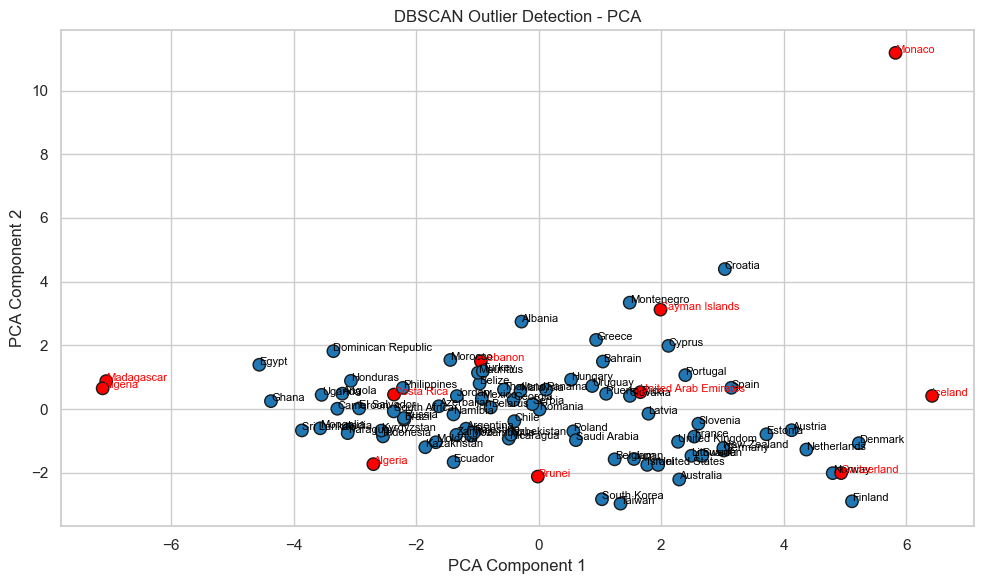

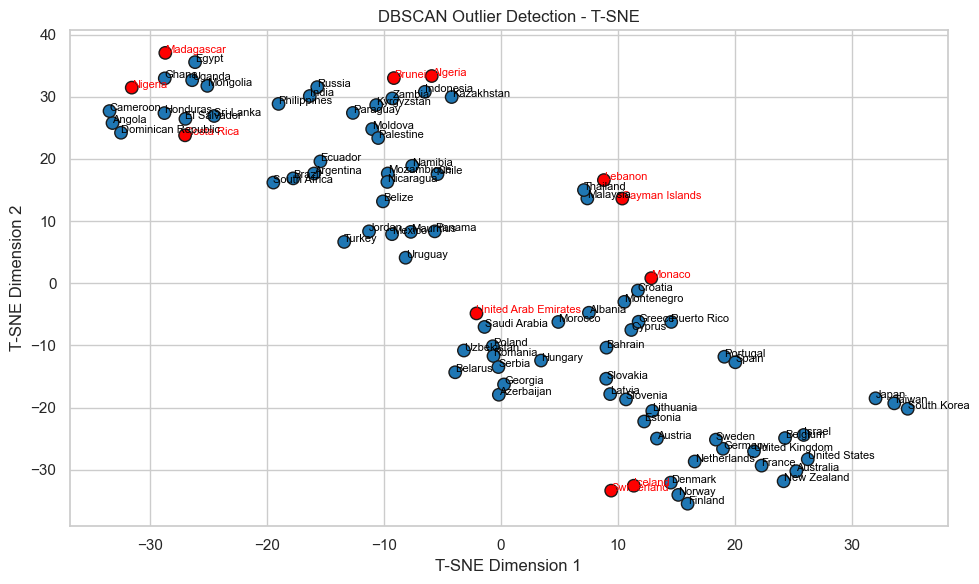


Outlier Countries Detected:
             CountryName CountryCode
1                Algeria         DZA
12                Brunei         BRN
14        Cayman Islands         CYM
16            Costa Rica         CRI
33               Iceland         ISL
42               Lebanon         LBN
44            Madagascar         MDG
49                Monaco         MCO
58               Nigeria         NGA
78           Switzerland         CHE
83  United Arab Emirates         ARE


In [41]:
outliers = utils.detect_dbscan_outliers(default_dataset)

#### K-Means

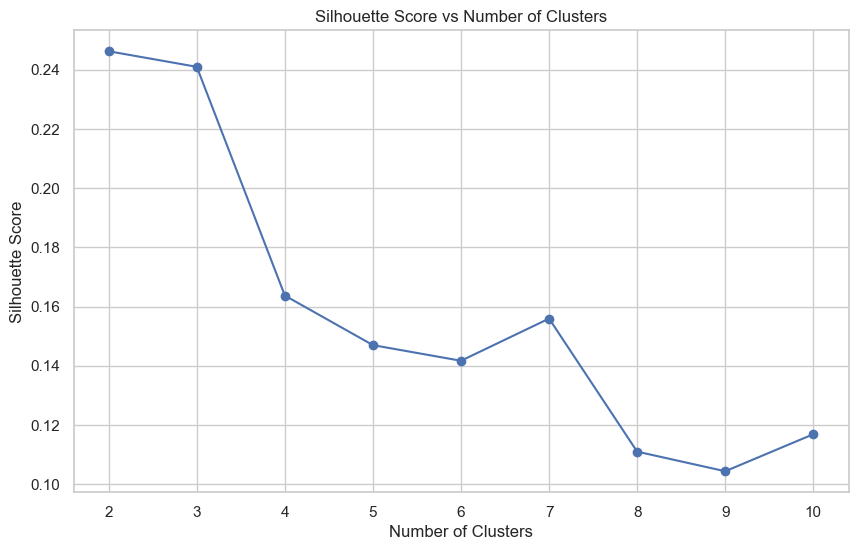

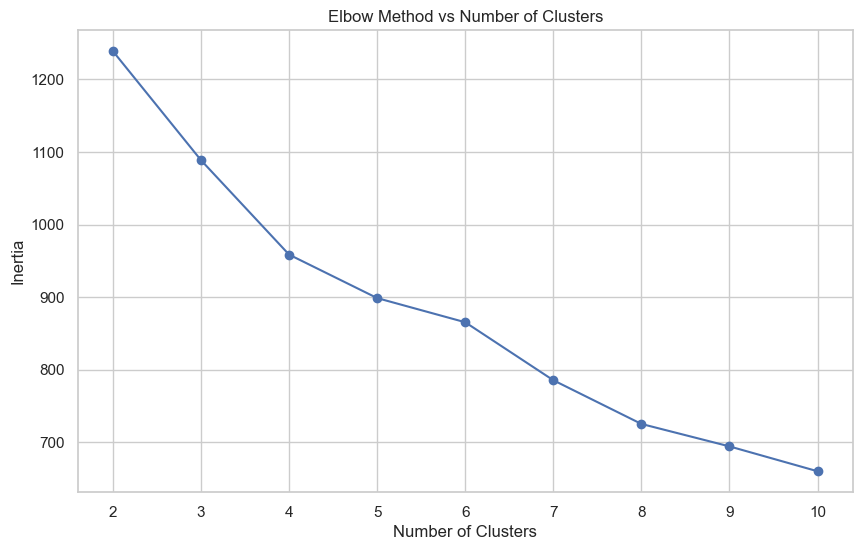

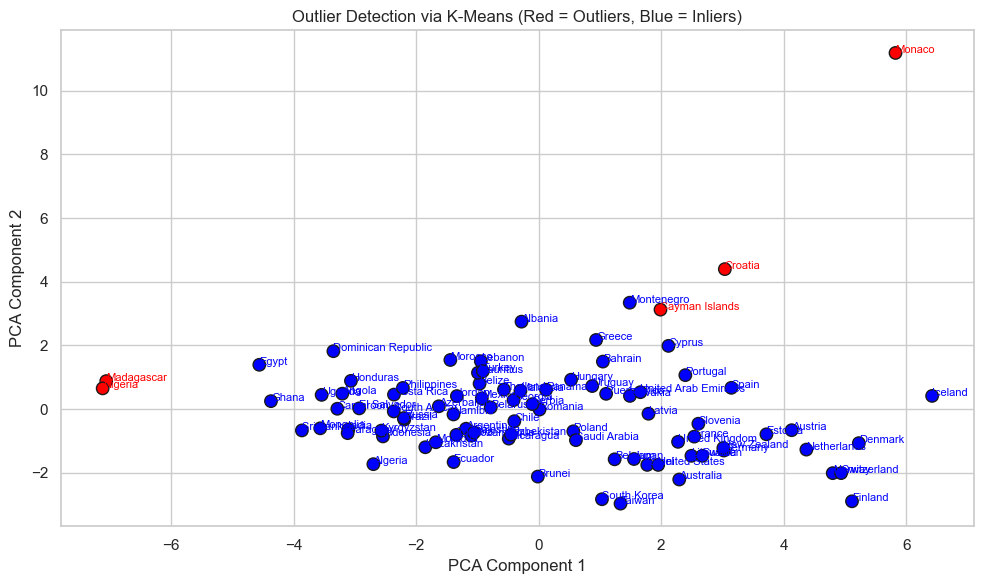

Outlier Countries:
['Cayman Islands', 'Croatia', 'Madagascar', 'Monaco', 'Nigeria']

Validation Indices:
Davies-Bouldin Index: 1.514414770301175
Calinski-Harabasz Index: 31.893141955788348
Dunn Index: 0.0784326061480343


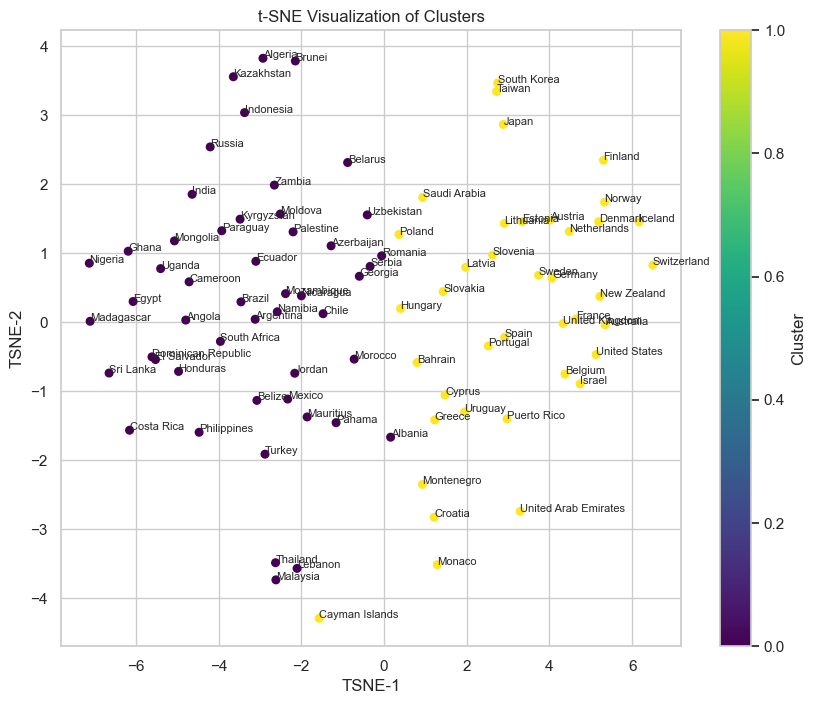

In [42]:
default_dataset_copy = default_dataset.copy()
numerical_features_df_default = default_dataset_copy.drop(columns=['CountryCode', 'CountryName'])

outliers_df,cluster_labels,kmeans_indices = utils.detect_kmeans_outliers(default_dataset_copy)
utils.applyTSNE(numerical_features_df_default, cluster_labels, default_dataset_copy)

In [43]:
# K-means results
kmeans_row = pd.DataFrame([{
    "Dataset": "Baseline Dataset",
    "Algorithm": "K-means",
    "Davies-Bouldin Index": kmeans_indices["Davies-Bouldin Index"],
    "Calinski-Harabasz Index": kmeans_indices["Calinski-Harabasz Index"],
    "Dunn Index": kmeans_indices["Dunn Index"]
}])

# Append K-means row
results_df = pd.concat([results_df, kmeans_row], ignore_index=True)

results_df.head()

,Dataset,Algorithm,Davies-Bouldin Index,Calinski-Harabasz Index,Dunn Index
0,Baseline Dataset,K-means,1.514415,31.893142,0.078433


#### Hierarchical clustering

**1: Evaluate Cluster Quality for Different `k`**
We start by evaluating different choices for the number of clusters (`k`) using two methods:
- **Silhouette Score**: Measures how similar each point is to its own cluster vs. other clusters.
- **Elbow Method (KMeans Inertia)**: Measures the within-cluster sum of squares. We look for a point ("elbow") where adding more clusters yields diminishing returns.

These plots guide the selection of an appropriate `k`.

**2: Visualize Cluster Structure via Dendrograms**
We generate multiple **dendrograms** (tree diagrams) to visually assess how the data naturally clusters. This helps validate our `k` choice and provides interpretability into the hierarchy of merges.

In [44]:
default_dataset_copy = default_dataset.copy()
numerical_features_df_default = default_dataset_copy.drop(columns=['CountryCode', 'CountryName'])
labels_df = default_dataset_copy[['CountryCode', 'CountryName']]

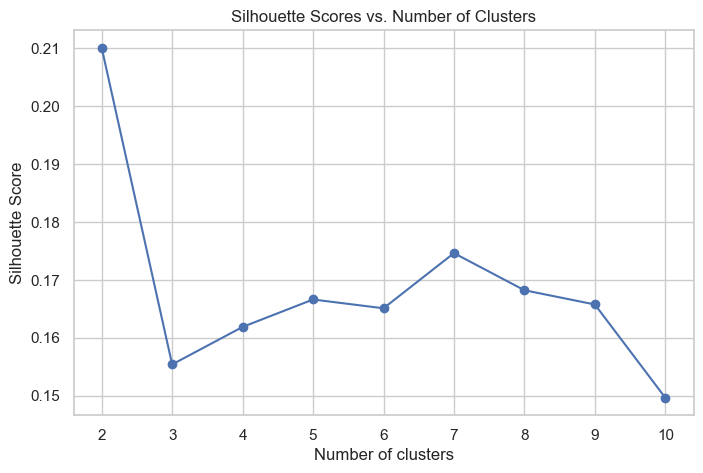

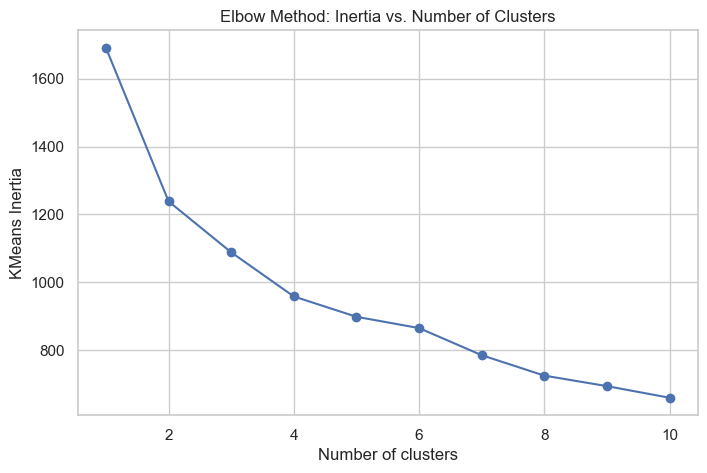

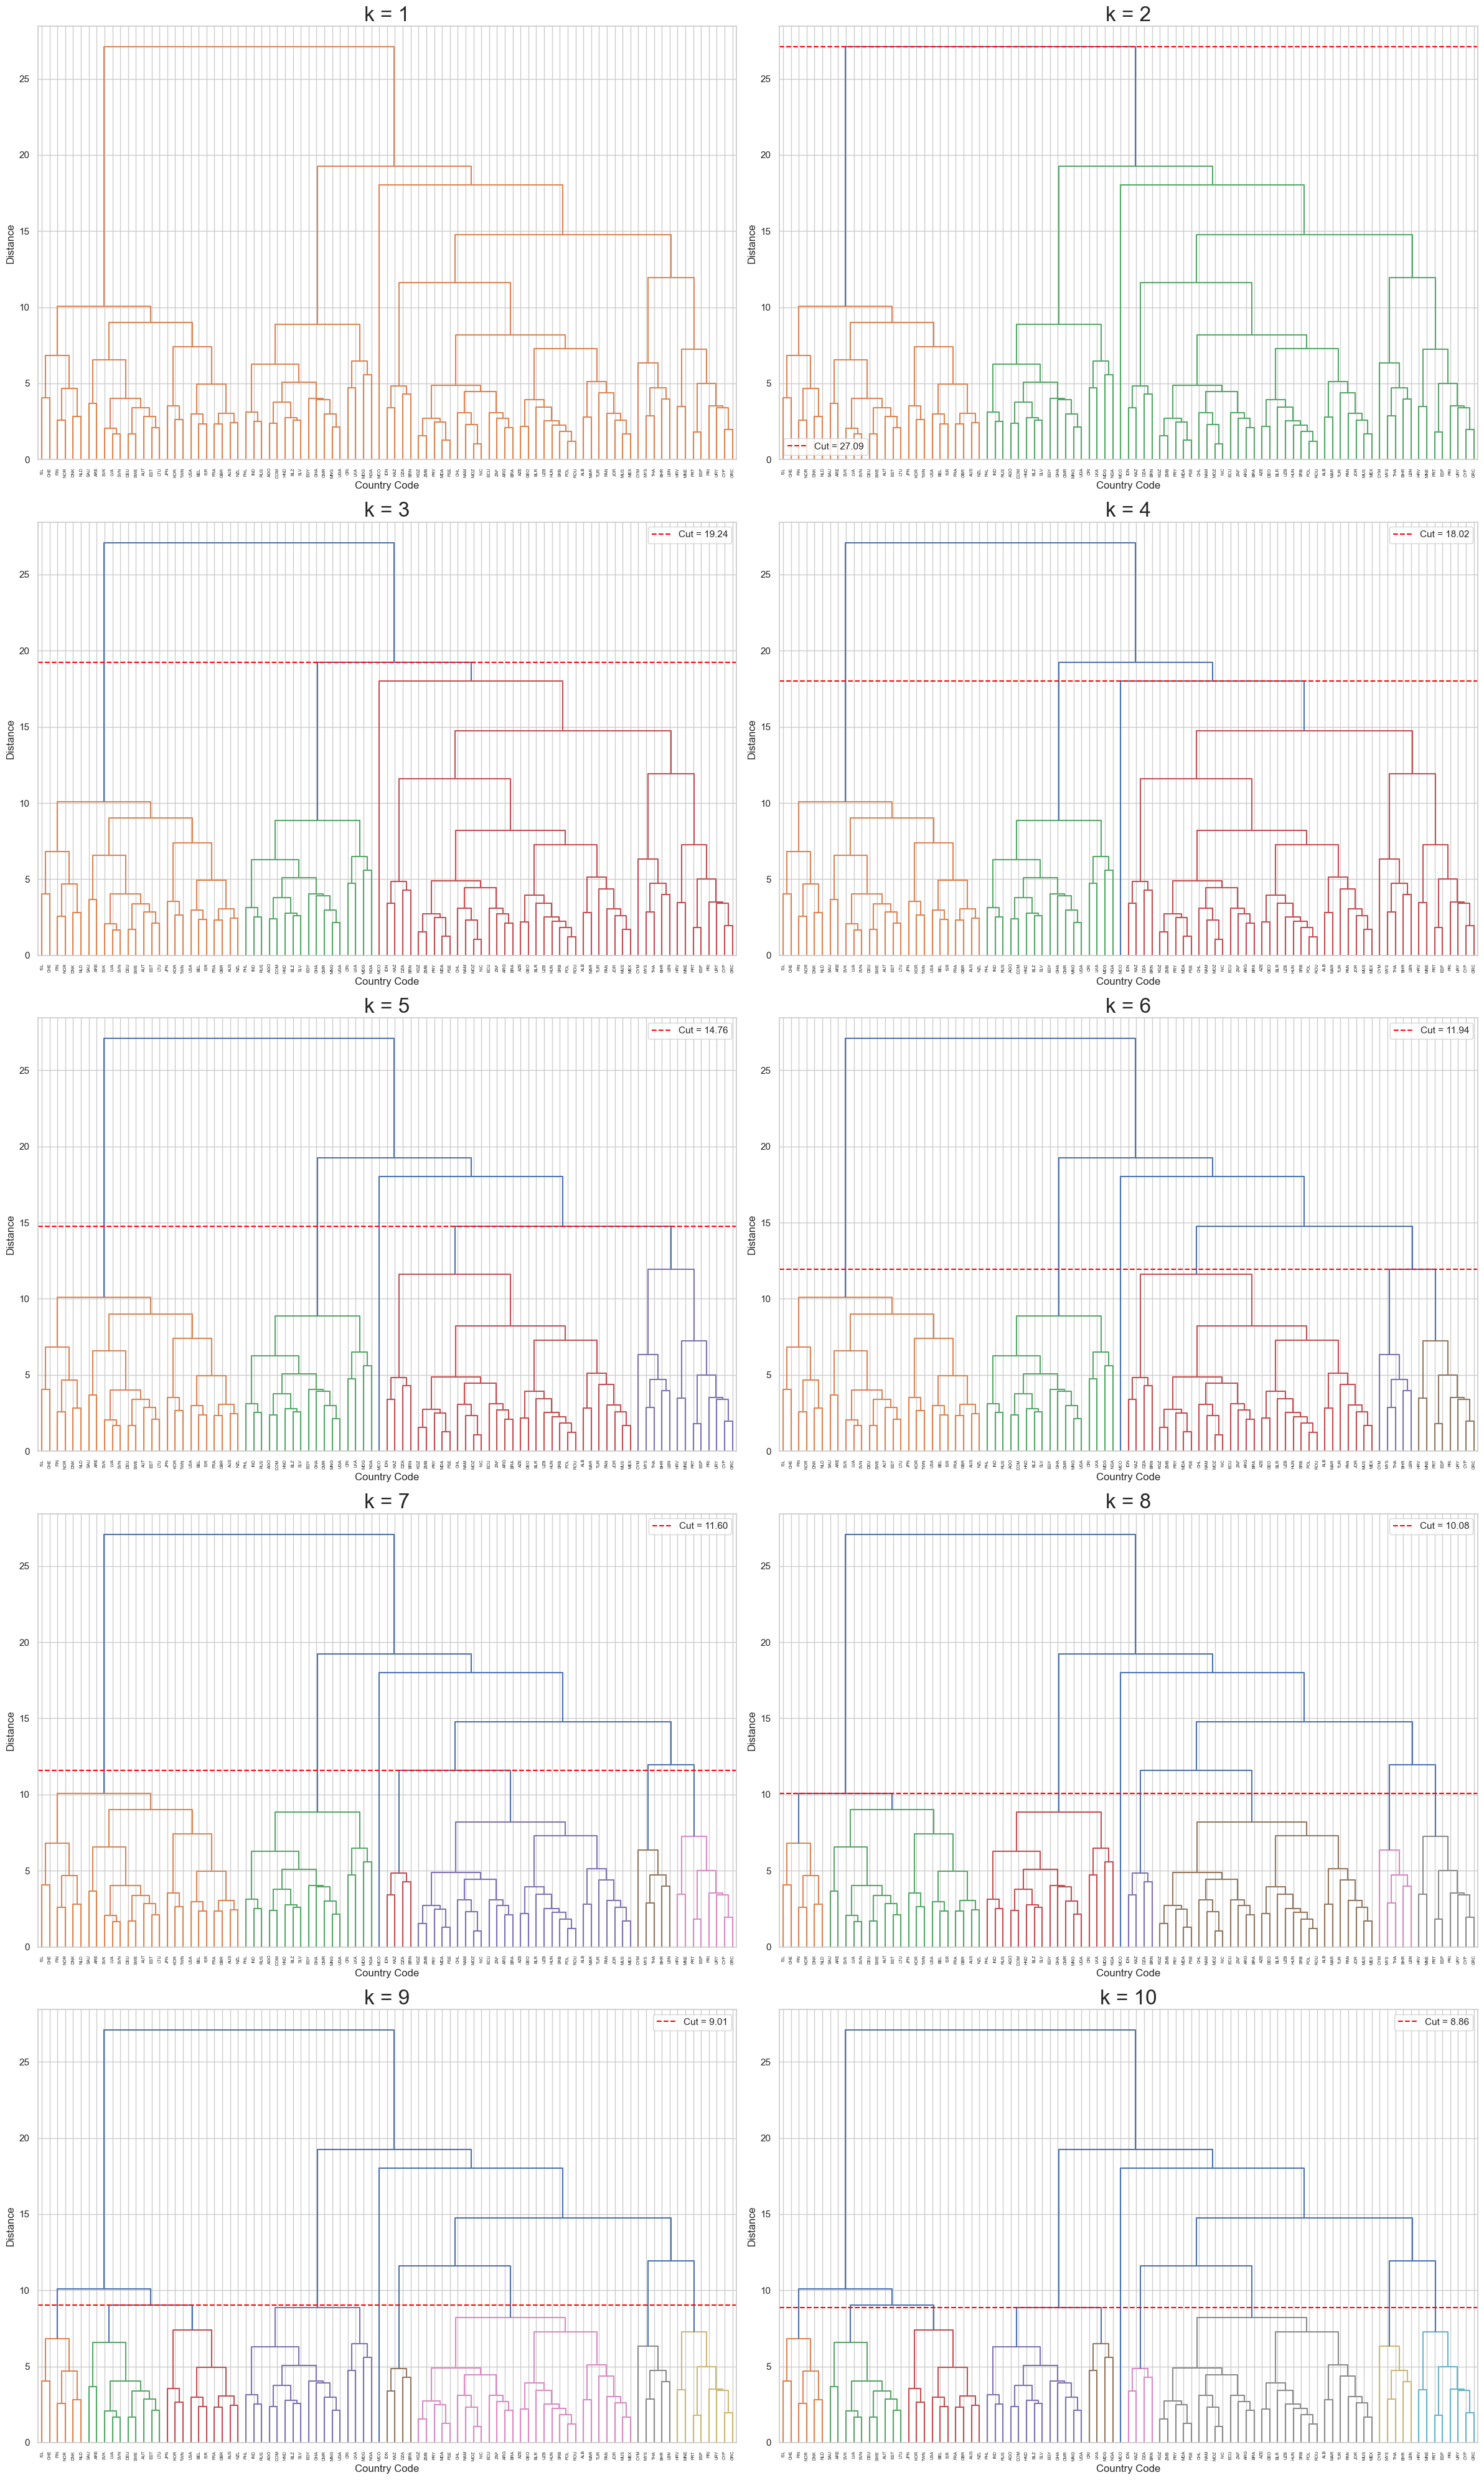

In [45]:
# Plot Silhouette and Elbow methods to aid in choosing the number of clusters
silhouette_scores = utils.plot_silhouette_scores(numerical_features_df_default, k_range=range(2, 11))
inertias = utils.plot_elbow_method(numerical_features_df_default, k_range=range(1, 11))

# Plot multiple dendrograms for k = 1 to 10 to visually compare cluster separations
utils.plot_multiple_dendrograms(numerical_features_df_default, countries=labels_df, max_k=10)

**3: Perform Agglomerative Clustering**
Using the selected number of clusters, we run the full hierarchical clustering pipeline:
- Optionally apply PCA (used to visualize in comparison with t-SNE, not used for final results).
- Fit an Agglomerative Clustering model.
- Attach cluster labels to countries and features.
- Visualize results in:
  - A full dendrogram for the chosen `k`
  - A **t-SNE scatter plot** colored by cluster, overlaid with country names for interpretability.

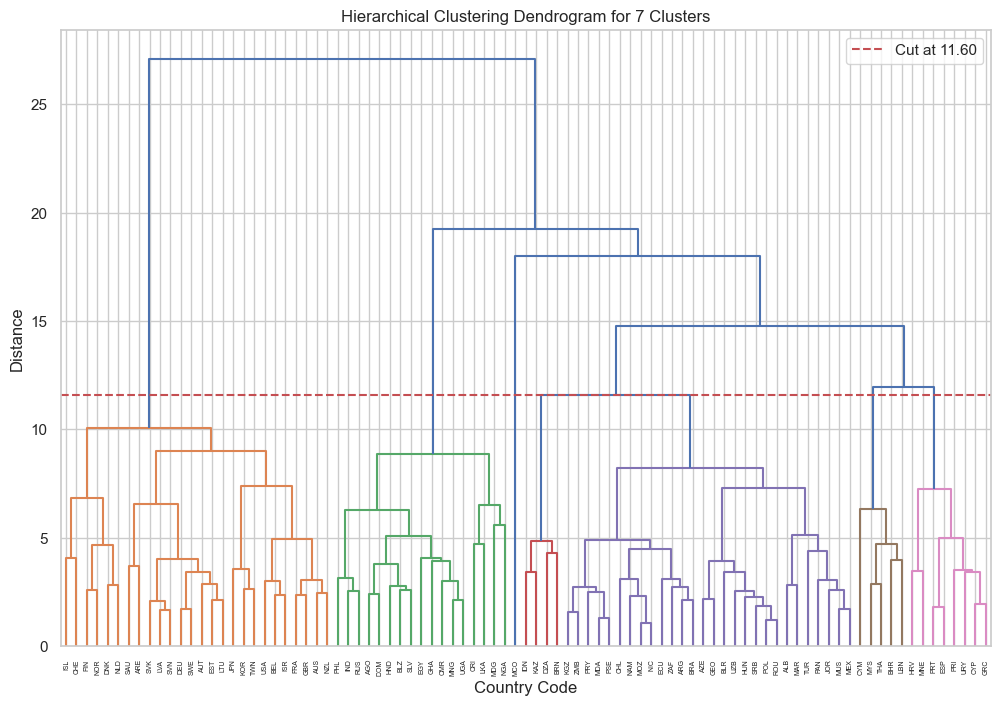

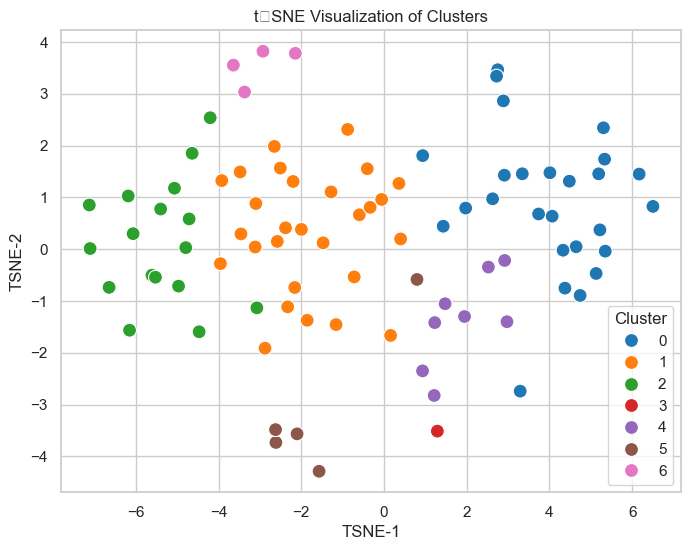

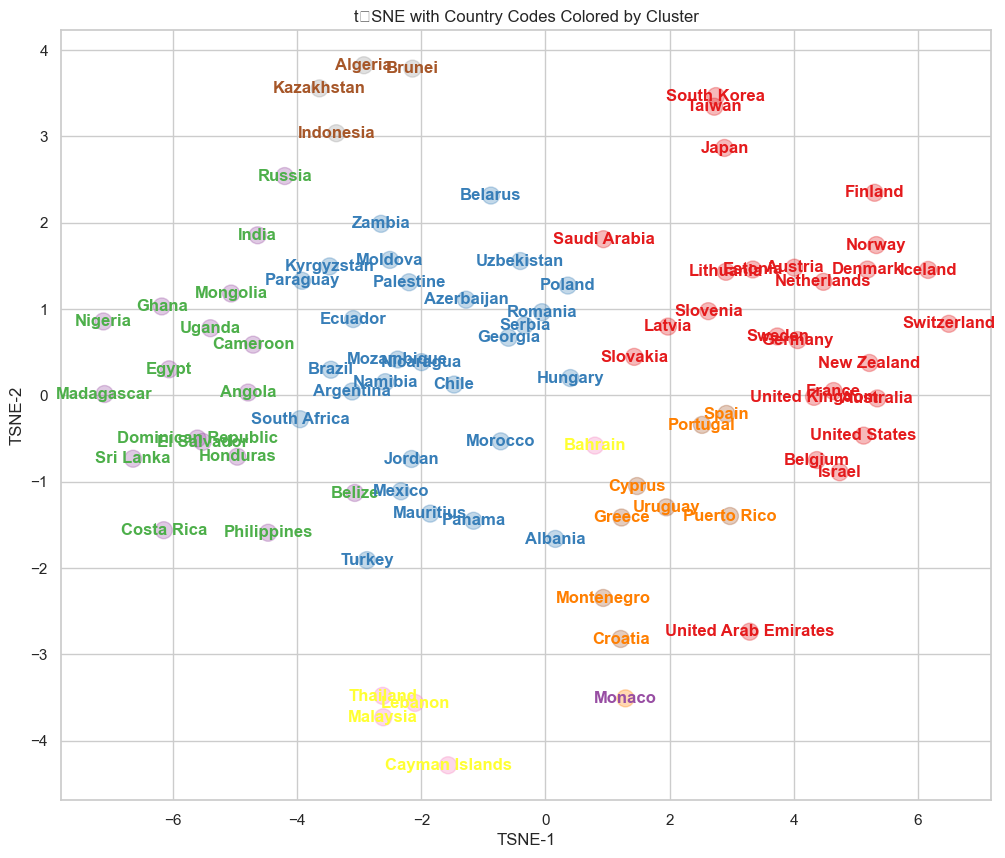

Validation Indices:
Davies-Bouldin Index: 1.2458759294397501
Calinski-Harabasz Index: 18.026237172211303
Dunn Index: 0.2504850511409487
Cluster mapping:
Cluster 0: Australia, Austria, Belgium, Denmark, Estonia, Finland, France, Germany, Iceland, Israel, Japan, Latvia, Lithuania, Netherlands, New Zealand, Norway, Saudi Arabia, Slovakia, Slovenia, South Korea, Sweden, Switzerland, Taiwan, United Arab Emirates, United Kingdom, United States
Cluster 1: Albania, Argentina, Azerbaijan, Belarus, Brazil, Chile, Ecuador, Georgia, Hungary, Jordan, Kyrgyzstan, Mauritius, Mexico, Moldova, Morocco, Mozambique, Namibia, Nicaragua, Palestine, Panama, Paraguay, Poland, Romania, Serbia, South Africa, Turkey, Uzbekistan, Zambia
Cluster 2: Angola, Belize, Cameroon, Costa Rica, Dominican Republic, Egypt, El Salvador, Ghana, Honduras, India, Madagascar, Mongolia, Nigeria, Philippines, Russia, Sri Lanka, Uganda
Cluster 3: Monaco
Cluster 4: Croatia, Cyprus, Greece, Montenegro, Portugal, Puerto Rico, Spain, U

In [46]:
k_opt = 7
# Perform hierarchical clustering on the selected features using a chosen k
df_combined, cluster_labels, hierarchical_indices = utils.run_clustering_analysis(
    numerical_features_df_default,
    countries=labels_df,
    k_clusters=k_opt,
    plot_dendrogram_flag=True,
    plot_tsne_flag=True,
    compute_validation=True
)

 **Output**
The final result is a `DataFrame` containing:
- Country information (CountryCode, CountryName)
- All features used in clustering
- Cluster assignments
- t-SNE coordinates for visualization

In [47]:
# Hierarchical Clustering results
hierarchical_row = pd.DataFrame([{
    "Dataset": "Baseline Dataset",
    "Algorithm": "Hierarchical Clustering",
    "Davies-Bouldin Index": hierarchical_indices["Davies-Bouldin Index"],
    "Calinski-Harabasz Index": hierarchical_indices["Calinski-Harabasz Index"],
    "Dunn Index": hierarchical_indices["Dunn Index"]
}])

# Append Hierarchical Clustering row
results_df = pd.concat([results_df, hierarchical_row], ignore_index=True)

results_df.head()

,Dataset,Algorithm,Davies-Bouldin Index,Calinski-Harabasz Index,Dunn Index
0,Baseline Dataset,K-means,1.514415,31.893142,0.078433
1,Baseline Dataset,Hierarchical Clustering,1.245876,18.026237,0.250485


### Improvements

**Refining the Dataset: Addressing Bias and Correlation**

To improve our clustering results, we revisited our dataset for a deeper analysis of potential bias and redundancy in the features. During this process, we closely examined the Numbeo indices and discovered that some features were either:

- Heavily overlapping in the metrics used for their calculation
- Directly derived from one another, essentially duplicating information

This raised concerns about bias and feature redundancy, which could negatively influence the clustering outcomes.

**Feature Removal to Reduce Bias**

To mitigate this, we looked at the following columns from our dataset:

- `TrafficIndex`  
- `TrafficTimeIndexMinutes`  
- `TrafficInefficiencyIndex`  

- `ClimateIndex`
- `PollutionIndex`


These columns were either derivative of each other or based on overlapping sub-indicators, which could unfairly weight certain dimensions of the data in the clustering algorithm.

**Exploring Correlation for Further Bias Reduction**

Given our concern about feature interdependence, we further investigated correlation between features to ensure we weren’t unintentionally introducing bias through highly correlated variables.

- We used the **Spearman correlation coefficient**, which is more appropriate than Pearson in this context because most of our features are not normally distributed.
- We also examined the **p-values** to assess the **statistical significance** of the correlations, ensuring we only considered relevant associations.

This step helped us identify and address hidden redundancies, enhancing the fairness and robustness of our clustering process.


In [48]:
default_dataset.columns

Index(['CountryName', 'CountryCode', 'TourismEmploymentPer1000',
       'FoodEmploymentPer1000', 'TourismGDPPercentage',
       'BusinessToPersonalRatio', 'AverageStayDays', 'InboundArrivalsPer1000',
       'DomesticTouristsPer1000', 'InboundToOutboundRatio',
       'CostOfLivingIndex', 'GroceriesCostIndex', 'RestaurantPriceIndex',
       'SafetyIndex', 'HealthCareIndex', 'QualityOfLifeIndex', 'ClimateIndex',
       'ReverseTrafficInefficiencyIndex', 'ReverseTrafficTimeIndexMinutes',
       'ReverseTrafficIndex', 'ReversePollutionIndex'],
      dtype='object')

In [49]:
all_numerical_features_df = default_dataset.copy()
all_numerical_features_df.drop(columns=["CountryName","CountryCode"], inplace=True)

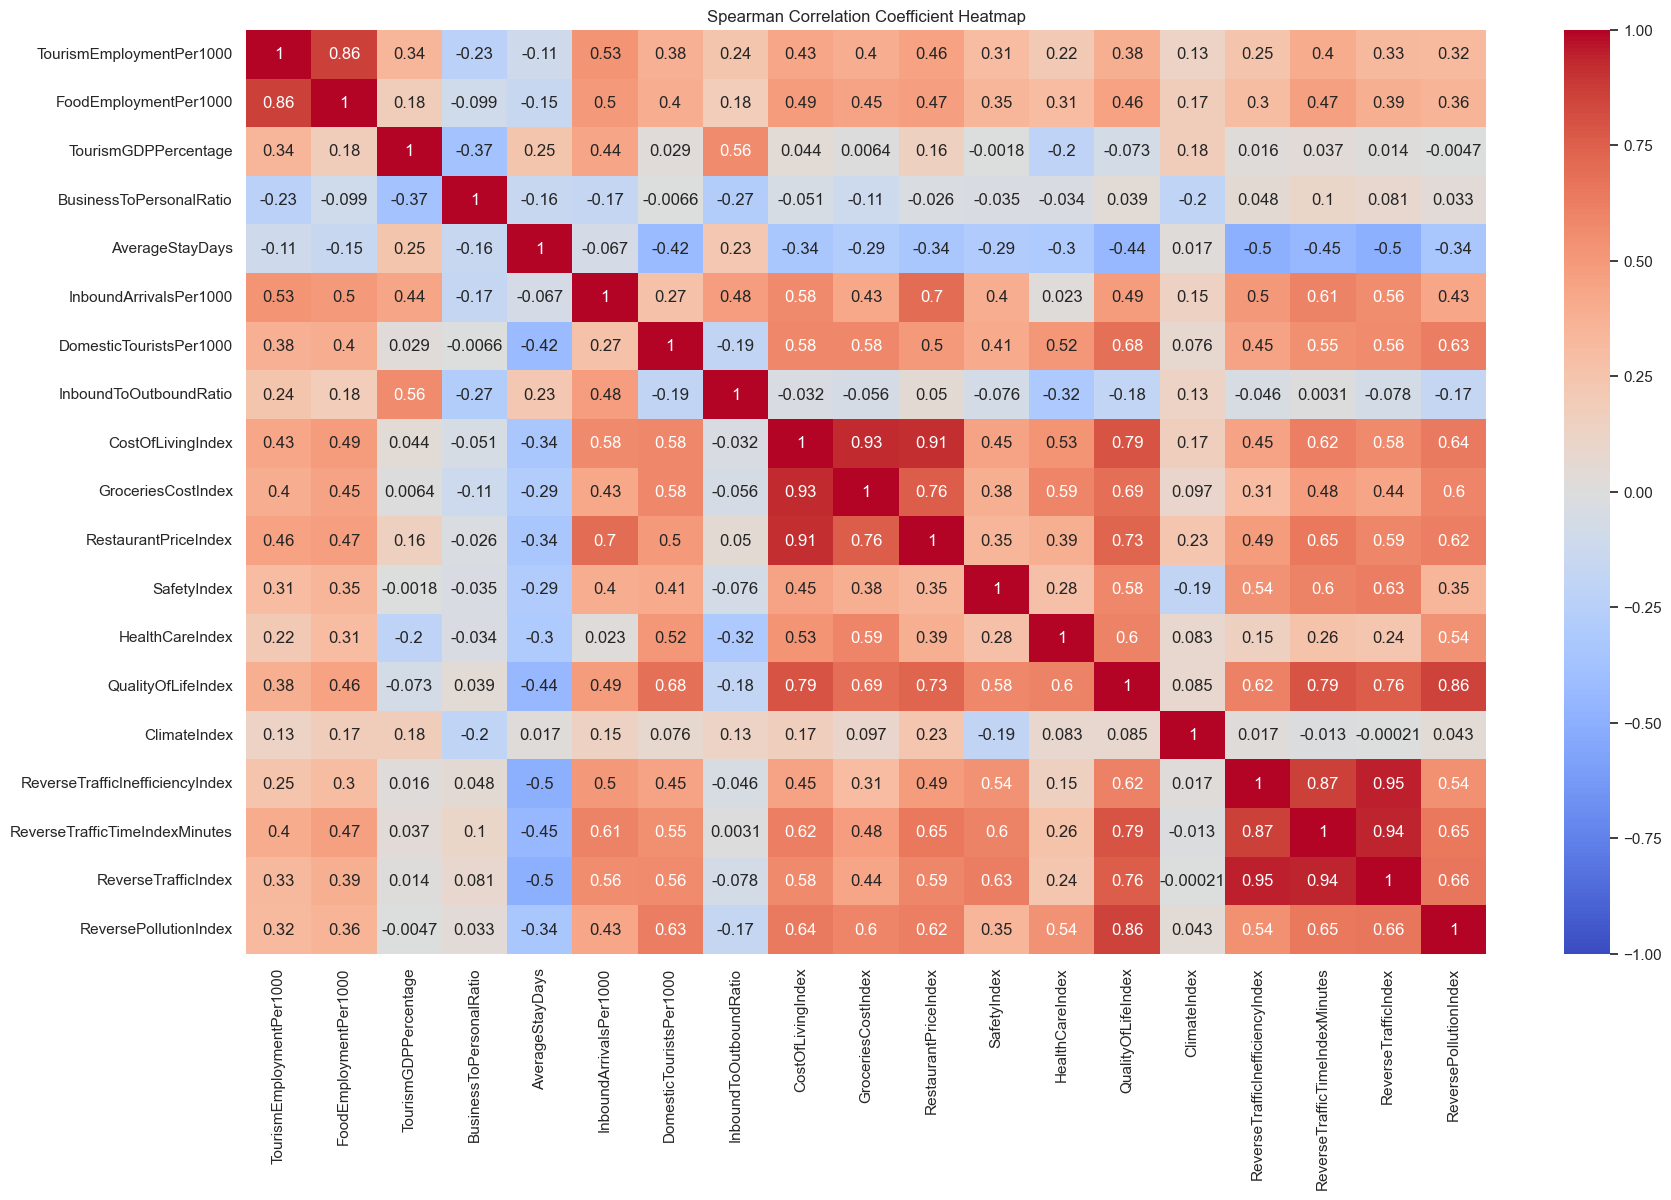

In [50]:
columns = all_numerical_features_df.columns
n = len(columns)

# Empty DataFrames
spearman_corr_df = pd.DataFrame(np.zeros((n, n)), columns=columns, index=columns)

# Compute pairwise correlations
for i in range(n):
    for j in range(n):
        col1 = columns[i]
        col2 = columns[j]
        rho, p = spearmanr(all_numerical_features_df[col1], all_numerical_features_df[col2], nan_policy='omit')
        spearman_corr_df.loc[col1, col2] = rho
plt.figure(figsize=(20, 12))
sns.heatmap(spearman_corr_df, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Spearman Correlation Coefficient Heatmap')
plt.show()

To check for statistical relevance, because we have less than the recommended sample side in our data (500), we will use permutation testing. 

In [51]:
def permutation_test_spearman(x, y, n_permutations=1000, random_state=None):
    rng = np.random.default_rng(random_state)
    
    # Actual correlation with nan_policy='omit'
    rho_actual, _ = spearmanr(x, y, nan_policy='omit')

    # Null distribution via permutations (with a progress bar)
    rhos_perm = np.zeros(n_permutations)
    for i in tqdm(range(n_permutations), desc="Permutations", leave=False):  # Add progress bar here
        y_perm = rng.permutation(y)
        rho, _ = spearmanr(x, y_perm, nan_policy='omit')
        rhos_perm[i] = rho

    # Two-sided p-value
    p_value = np.mean(np.abs(rhos_perm) >= np.abs(rho_actual))

    return rho_actual, p_value

In [52]:

# columns = list(all_numerical_features_df.columns)
# n = len(columns)

# # Empty DataFrames
# perm_corr_df = pd.DataFrame(np.zeros((n, n)), columns=columns, index=columns)
# perm_pval_df = pd.DataFrame(np.ones((n, n)), columns=columns, index=columns)

# # Iterate over each pair of columns with a progress bar
# for i in tqdm(range(n), desc="Columns", leave=False):  # Progress bar for columns
#     for j in range(i, n):
#         col1 = columns[i]
#         col2 = columns[j]
#         x = all_numerical_features_df[col1].values
#         y = all_numerical_features_df[col2].values

#         # Run the permutation test
#         rho, p = permutation_test_spearman(x, y, n_permutations=1000)
#         perm_corr_df.loc[col1, col2] = rho
#         perm_corr_df.loc[col2, col1] = rho
#         perm_pval_df.loc[col1, col2] = p
#         perm_pval_df.loc[col2, col1] = p


Because the process is quite time consuming we will save the results and import them for further plotting and usage.

In [53]:
# perm_corr_df.to_csv('Data/spearman_correlations.csv')
# perm_pval_df.to_csv('Data/spearman_pvalues.csv')

In [54]:
perm_corr_df = pd.read_csv('Data/spearman_correlations.csv', index_col=0) 
perm_pval_df = pd.read_csv('Data/spearman_pvalues.csv', index_col=0)

Let's look at all statistically significant correlations.

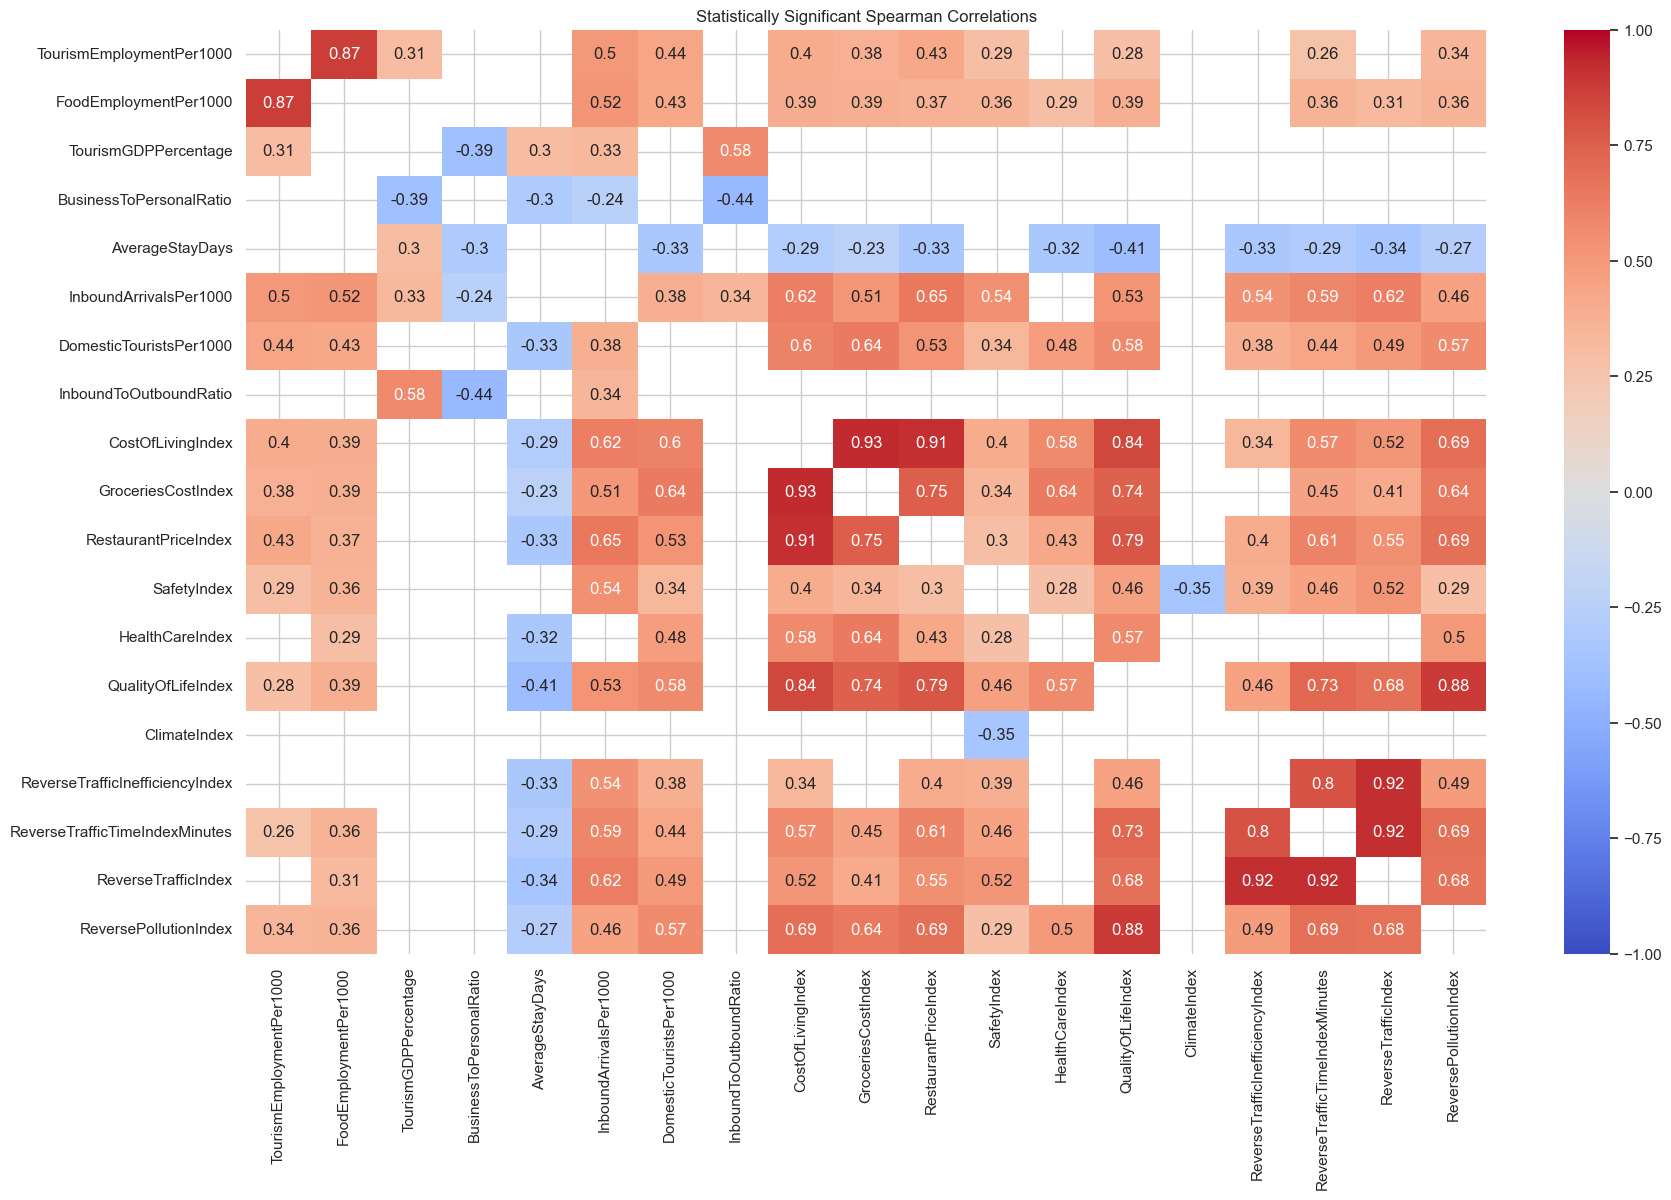

In [55]:

stat_signif_corr = perm_corr_df.copy()

# Create masks
mask_diag = np.eye(len(stat_signif_corr), dtype=bool)  
# mask_upper = np.triu(np.ones_like(stat_signif_corr, dtype=bool), k=1)  # Upper triangle without diagonal
mask_significant = perm_pval_df >= 0.05

full_mask =  mask_diag  | mask_significant  # Weak correlations, diagonal, upper triangle, and non-significant p-values

plt.figure(figsize=(20, 12))
sns.heatmap(stat_signif_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, mask=full_mask)
plt.title('Statistically Significant Spearman Correlations')
plt.show()


To make visualizations easier, let's plot only values that represent strong to very strong correlation (0.6 to 1 and -0.6 to -1), and statistical significance(p<0.05).


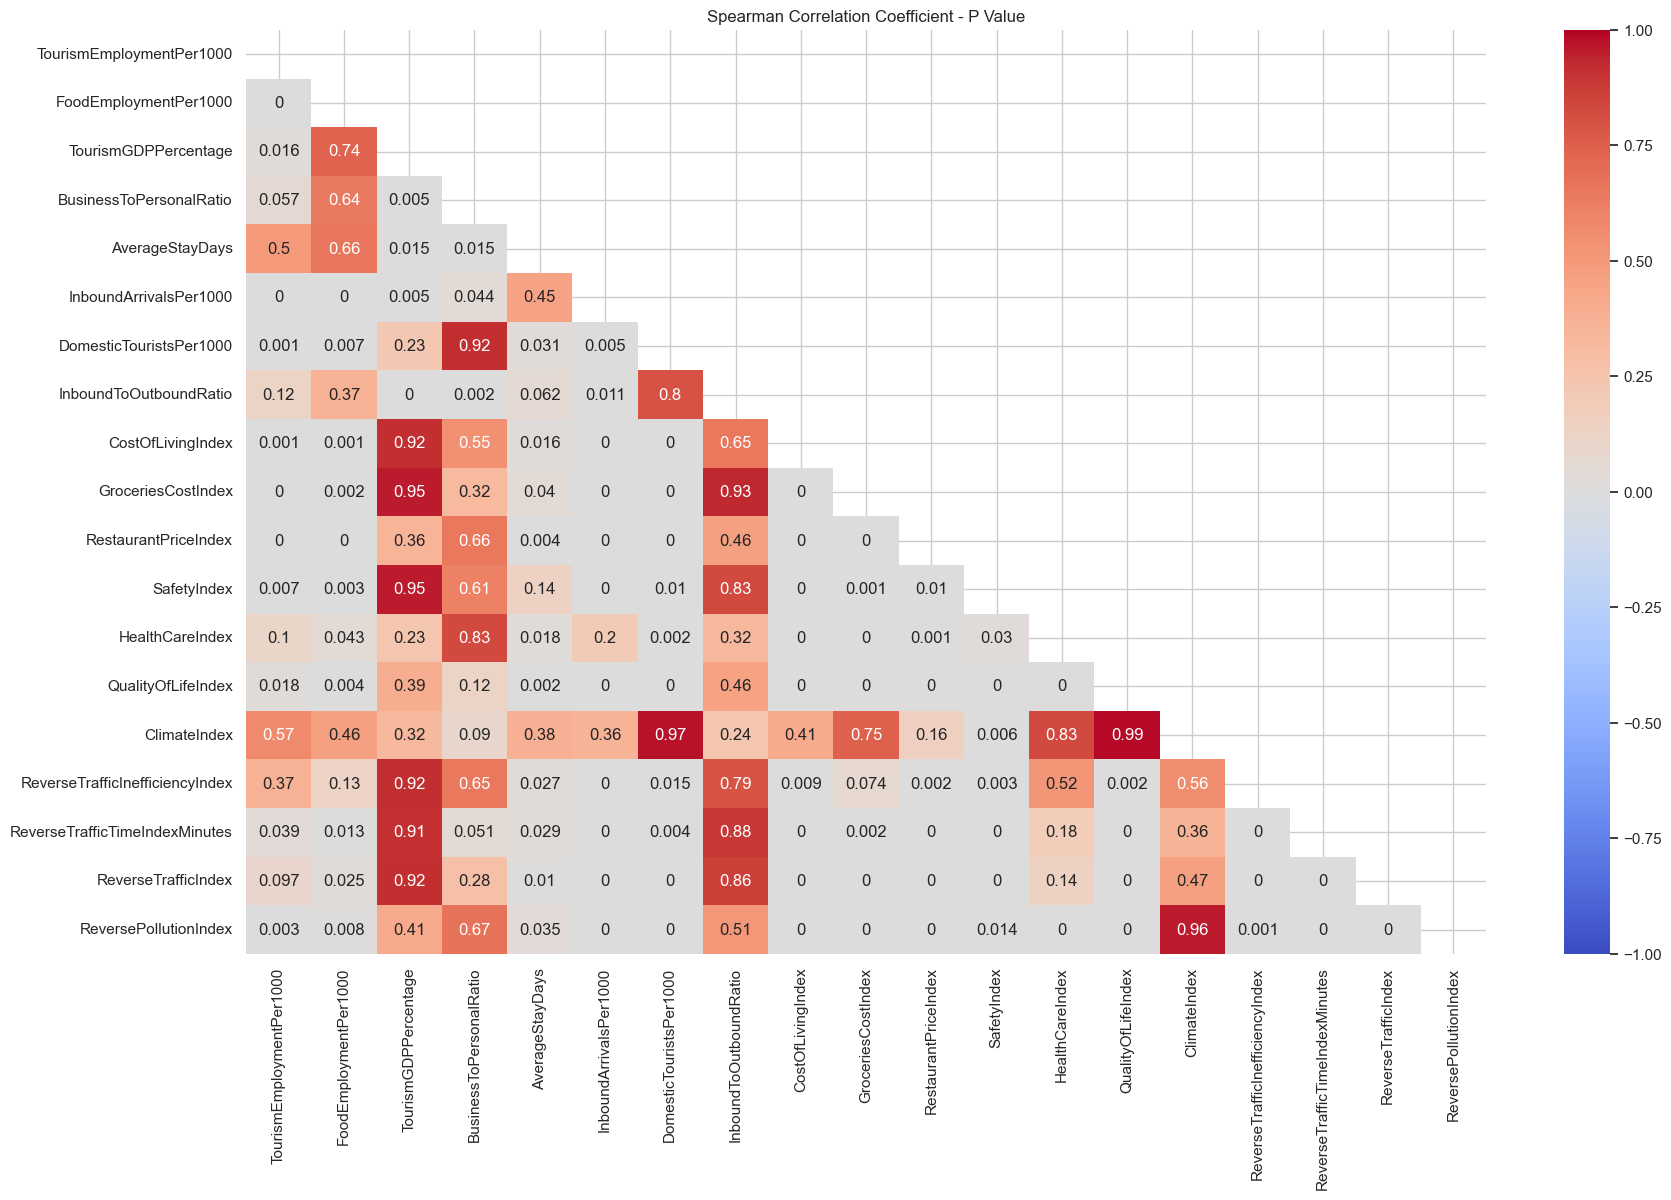

In [56]:
mask_diag = np.eye(len(perm_pval_df), dtype=bool)
mask_upper = np.triu(np.ones_like(perm_pval_df, dtype=bool), k=1)  # upper triangle without diagonal

full_mask =  mask_diag | mask_upper

plt.figure(figsize=(20, 12))
sns.heatmap(perm_pval_df, annot=True, cmap='coolwarm', vmin=-1, vmax=1, mask=full_mask)
plt.title('Spearman Correlation Coefficient - P Value')
plt.show()

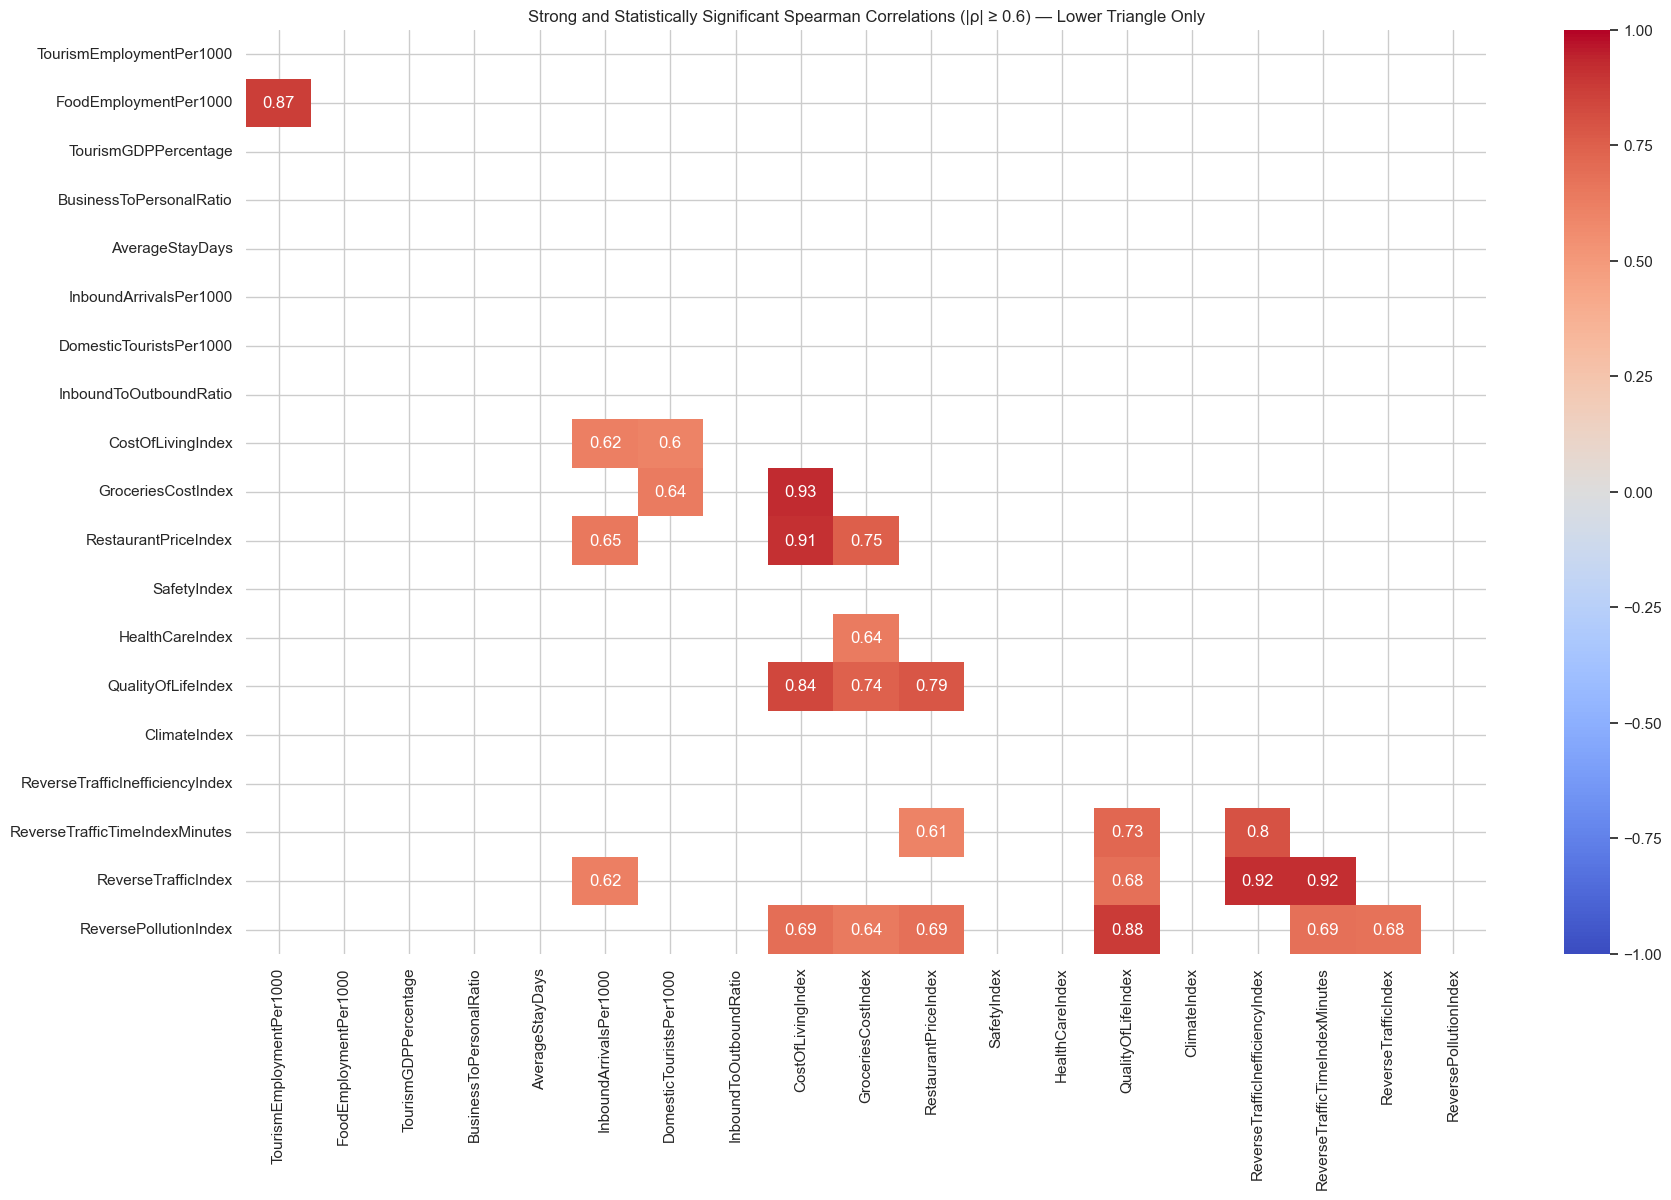

In [57]:

strong_corr = perm_corr_df.copy()

# Create masks
mask_weak = strong_corr.abs() < 0.6  
mask_diag = np.eye(len(strong_corr), dtype=bool)  
mask_upper = np.triu(np.ones_like(strong_corr, dtype=bool), k=1)  # Upper triangle without diagonal
mask_significant = perm_pval_df >= 0.05

full_mask = mask_weak | mask_diag | mask_upper | mask_significant  # Weak correlations, diagonal, upper triangle, and non-significant p-values

plt.figure(figsize=(20, 12))
sns.heatmap(strong_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, mask=full_mask)
plt.title('Strong and Statistically Significant Spearman Correlations (|ρ| ≥ 0.6) — Lower Triangle Only')
plt.show()


We are dropping features that are highly correlated.

In [58]:
all_numerical_features_df.columns

Index(['TourismEmploymentPer1000', 'FoodEmploymentPer1000',
       'TourismGDPPercentage', 'BusinessToPersonalRatio', 'AverageStayDays',
       'InboundArrivalsPer1000', 'DomesticTouristsPer1000',
       'InboundToOutboundRatio', 'CostOfLivingIndex', 'GroceriesCostIndex',
       'RestaurantPriceIndex', 'SafetyIndex', 'HealthCareIndex',
       'QualityOfLifeIndex', 'ClimateIndex', 'ReverseTrafficInefficiencyIndex',
       'ReverseTrafficTimeIndexMinutes', 'ReverseTrafficIndex',
       'ReversePollutionIndex'],
      dtype='object')

In [59]:
features_to_drop = ["CostOfLivingIndex", "FoodEmploymentPer1000", "QualityOfLifeIndex", "ReverseTrafficInefficiencyIndex", "ReverseTrafficTimeIndexMinutes"]
all_numerical_features_df.drop(inplace=True, columns=features_to_drop)

We notice that InboundToOutboundRatio is not correlated with any other columns, followed by ClimateIndex which is only correlated with SafetyIndex. 

In [60]:
feature_selection_df = pd.concat([default_dataset[["CountryName", "CountryCode"]], all_numerical_features_df] , axis=1)
feature_selection_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89 entries, 0 to 88
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CountryName               89 non-null     object 
 1   CountryCode               89 non-null     object 
 2   TourismEmploymentPer1000  89 non-null     float64
 3   TourismGDPPercentage      89 non-null     float64
 4   BusinessToPersonalRatio   89 non-null     float64
 5   AverageStayDays           89 non-null     float64
 6   InboundArrivalsPer1000    89 non-null     float64
 7   DomesticTouristsPer1000   89 non-null     float64
 8   InboundToOutboundRatio    89 non-null     float64
 9   GroceriesCostIndex        89 non-null     float64
 10  RestaurantPriceIndex      89 non-null     float64
 11  SafetyIndex               89 non-null     float64
 12  HealthCareIndex           89 non-null     float64
 13  ClimateIndex              89 non-null     float64
 14  ReverseTraff

In [61]:
feature_selection_df.describe()

,TourismEmploymentPer1000,TourismGDPPercentage,BusinessToPersonalRatio,AverageStayDays,InboundArrivalsPer1000,DomesticTouristsPer1000,InboundToOutboundRatio,GroceriesCostIndex,RestaurantPriceIndex,SafetyIndex,HealthCareIndex,ClimateIndex,ReverseTrafficIndex,ReversePollutionIndex
count,8.900000e+01,8.900000e+01,8.900000e+01,8.900000e+01,8.900000e+01,8.900000e+01,8.900000e+01,8.900000e+01,8.900000e+01,8.900000e+01,8.900000e+01,8.900000e+01,8.900000e+01,8.900000e+01
mean,1.322288e-16,1.746418e-17,-5.738231e-17,-1.289543e-16,-5.488743e-17,6.860929e-17,1.122697e-16,-5.862976e-17,5.114511e-17,1.381542e-16,4.699736e-16,-4.449858e-17,1.249001e-16,-3.025046e-17
std,1.005666e+00,1.005666e+00,1.005666e+00,1.005666e+00,1.005666e+00,1.005666e+00,1.005666e+00,1.005666e+00,1.005666e+00,1.005666e+00,1.005666e+00,1.005666e+00,1.005666e+00,1.005666e+00
min,-8.248084e-01,-1.470831e+00,-8.297294e-01,-8.061837e-01,-1.549582e+00,-1.238412e+00,-1.325698e+00,-1.538764e+00,-1.425830e+00,-2.285839e+00,-2.358880e+00,-3.237592e+00,-3.541823e+00,-1.957233e+00
25%,-5.940346e-01,-6.554017e-01,-5.743366e-01,-5.599769e-01,-4.665254e-01,-6.771156e-01,-5.628903e-01,-6.526709e-01,-7.159620e-01,-6.881257e-01,-6.784562e-01,-2.576465e-01,-4.340636e-01,-7.062014e-01
50%,-1.974161e-01,-2.085932e-01,-3.392996e-01,-3.619570e-01,-3.192122e-01,-1.717490e-01,-2.957303e-01,-1.932152e-01,-2.317108e-01,-8.807939e-02,-1.144962e-01,-1.432841e-02,3.940691e-02,-1.653670e-01
75%,2.338518e-01,3.663874e-01,1.590736e-01,1.299923e-01,1.404231e-01,3.522110e-01,1.011071e-01,7.048733e-01,5.111745e-01,8.156048e-01,7.703987e-01,6.428865e-01,7.486384e-01,6.304617e-01
max,5.716510e+00,4.408339e+00,5.481502e+00,5.359627e+00,6.643043e+00,4.474448e+00,5.146169e+00,3.935323e+00,3.202070e+00,1.994009e+00,2.442154e+00,1.649846e+00,1.691562e+00,2.142036e+00


In [62]:
labels_df = feature_selection_df[['CountryCode', 'CountryName']]
numerical_features_feature_selection_df = feature_selection_df.drop(columns=['CountryCode', 'CountryName'])

#### DBScan

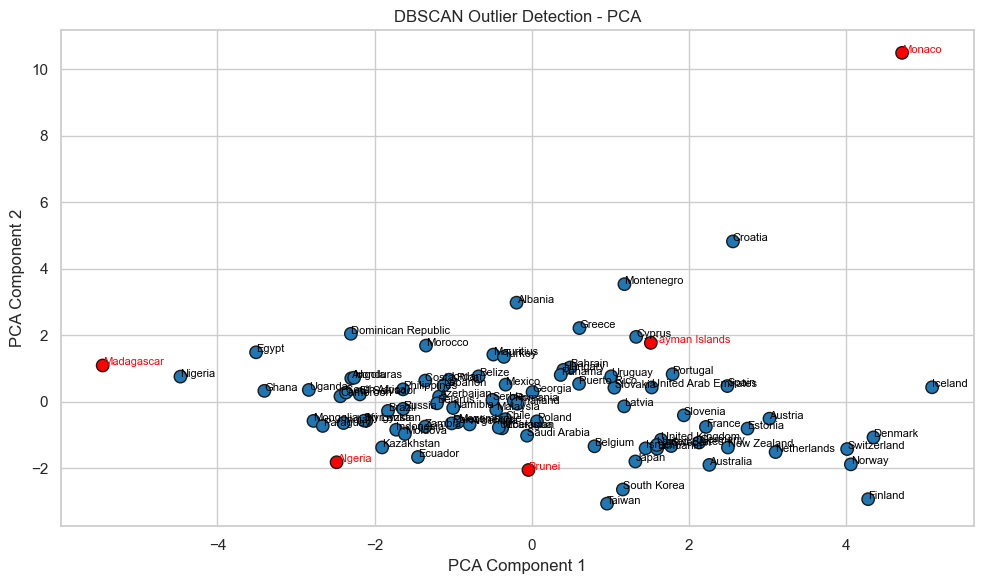

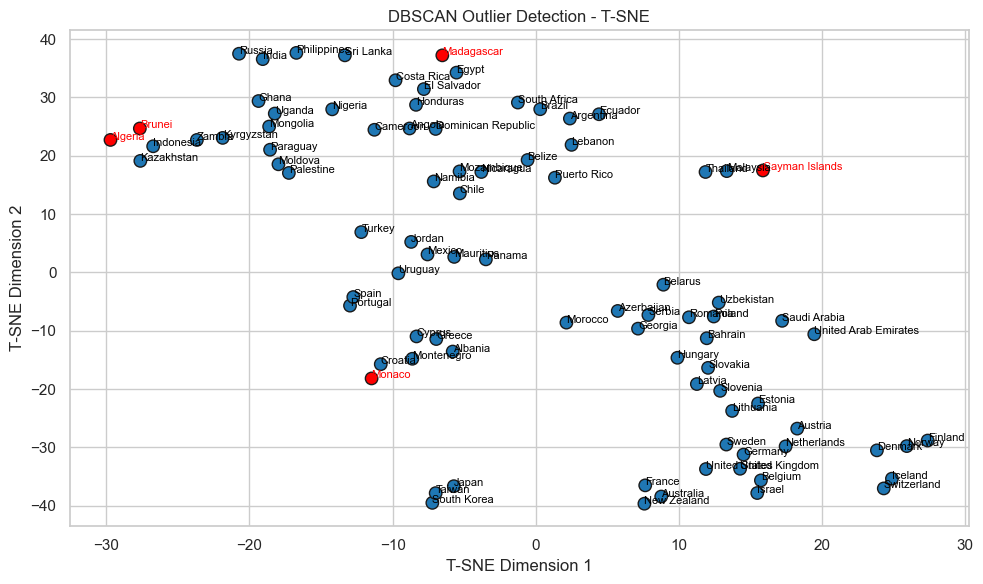


Outlier Countries Detected:
       CountryName CountryCode
1          Algeria         DZA
12          Brunei         BRN
14  Cayman Islands         CYM
44      Madagascar         MDG
49          Monaco         MCO


In [63]:
outliers = utils.detect_dbscan_outliers(feature_selection_df)

#### K-Means

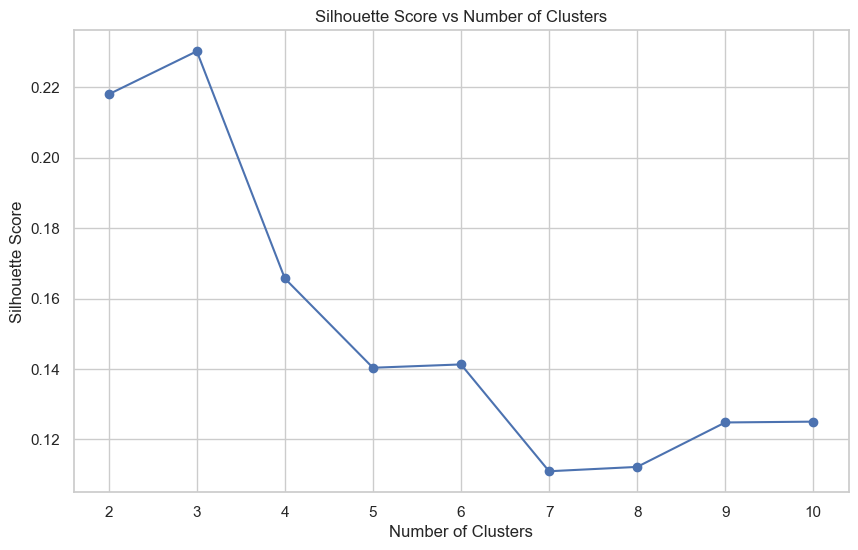

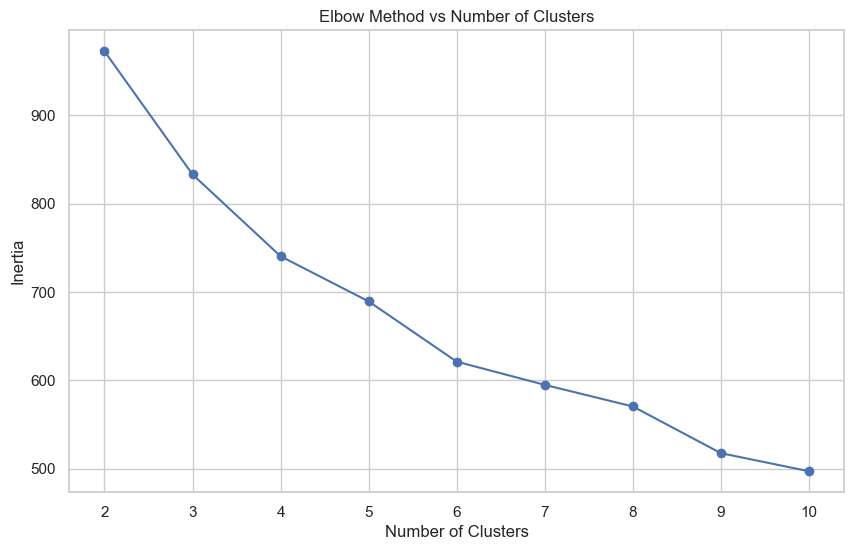

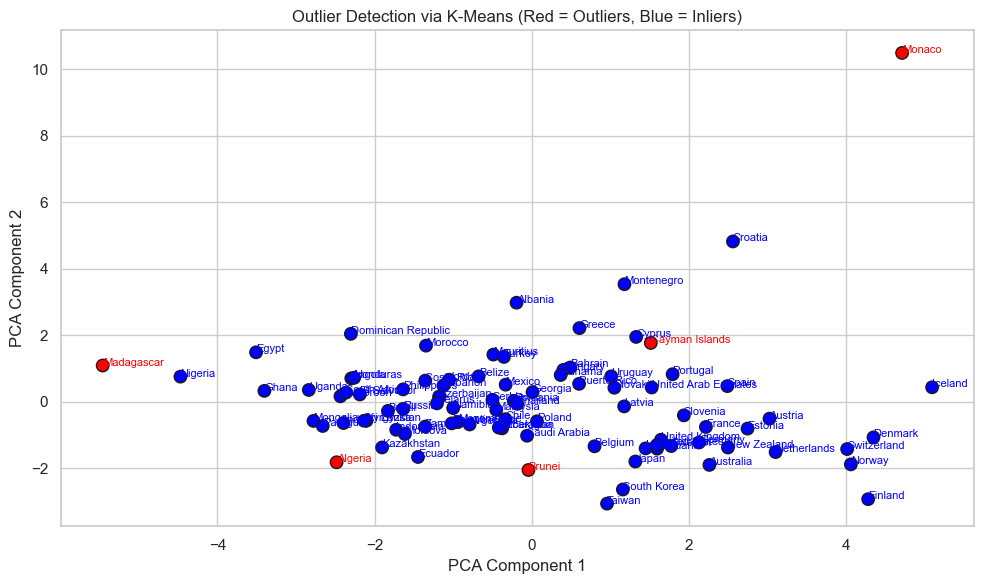

Outlier Countries:
['Algeria', 'Brunei', 'Cayman Islands', 'Madagascar', 'Monaco']

Validation Indices:
Davies-Bouldin Index: 1.394831085806932
Calinski-Harabasz Index: 20.864150804174823
Dunn Index: 0.14925746405538942


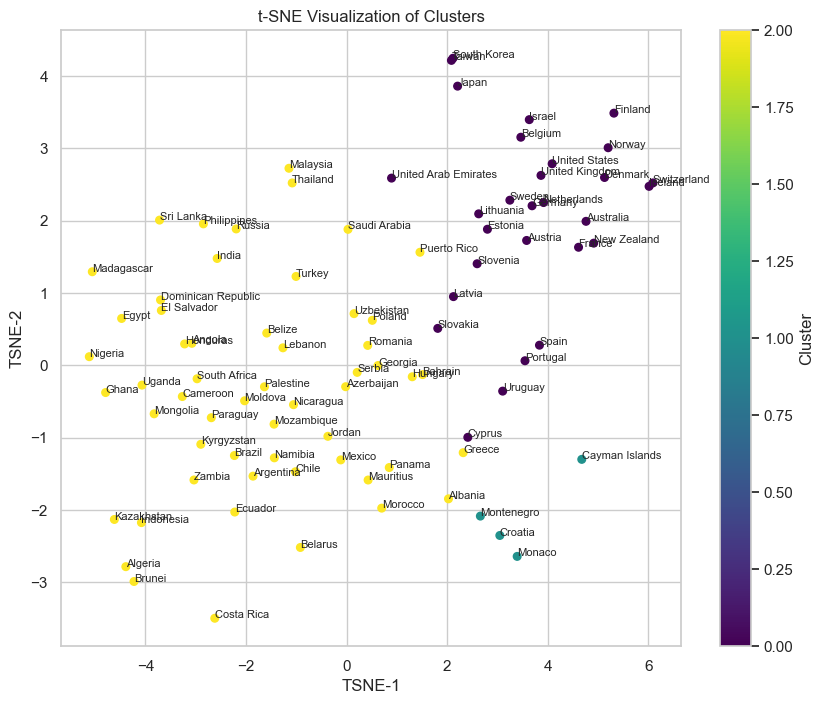

In [64]:
feature_selection_df_copy = feature_selection_df.copy()
numerical_features_feature_selection_df = feature_selection_df_copy.drop(columns=['CountryCode', 'CountryName'])

outliers_df,cluster_labels,kmeans_indices = utils.detect_kmeans_outliers(feature_selection_df_copy)
utils.applyTSNE(numerical_features_feature_selection_df, cluster_labels, feature_selection_df_copy)

In [65]:
# K-means results
kmeans_row = pd.DataFrame([{
    "Dataset": "Optimized Dataset",
    "Algorithm": "K-means",
    "Davies-Bouldin Index": kmeans_indices["Davies-Bouldin Index"],
    "Calinski-Harabasz Index": kmeans_indices["Calinski-Harabasz Index"],
    "Dunn Index": kmeans_indices["Dunn Index"]
}])

# Append K-means row
results_df = pd.concat([results_df, kmeans_row], ignore_index=True)

results_df.head()

,Dataset,Algorithm,Davies-Bouldin Index,Calinski-Harabasz Index,Dunn Index
0,Baseline Dataset,K-means,1.514415,31.893142,0.078433
1,Baseline Dataset,Hierarchical Clustering,1.245876,18.026237,0.250485
2,Optimized Dataset,K-means,1.394831,20.864151,0.149257


#### Hierarchical clustering

In [66]:
feature_selection_df_copy = feature_selection_df.copy()
numerical_features_feature_selection_df = feature_selection_df_copy.drop(columns=['CountryCode', 'CountryName'])
labels_df = feature_selection_df_copy[['CountryCode', 'CountryName']]

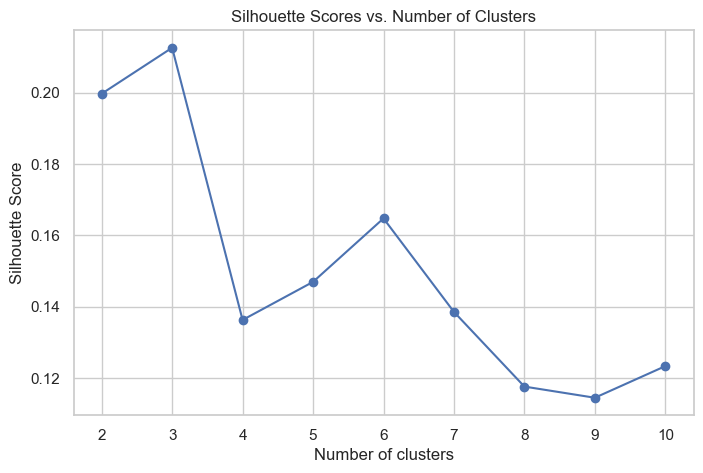

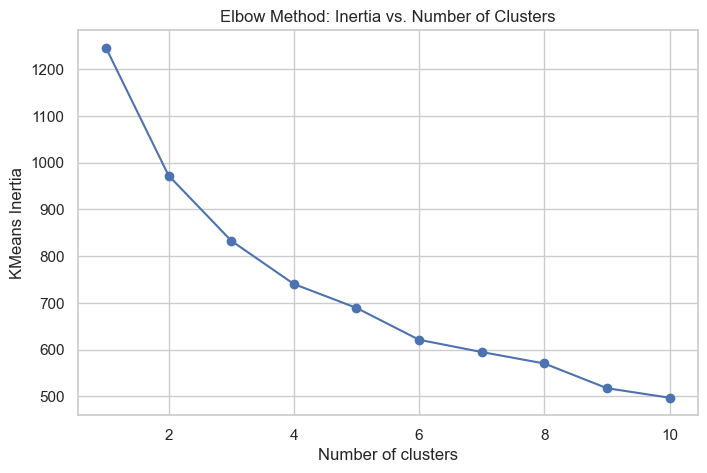

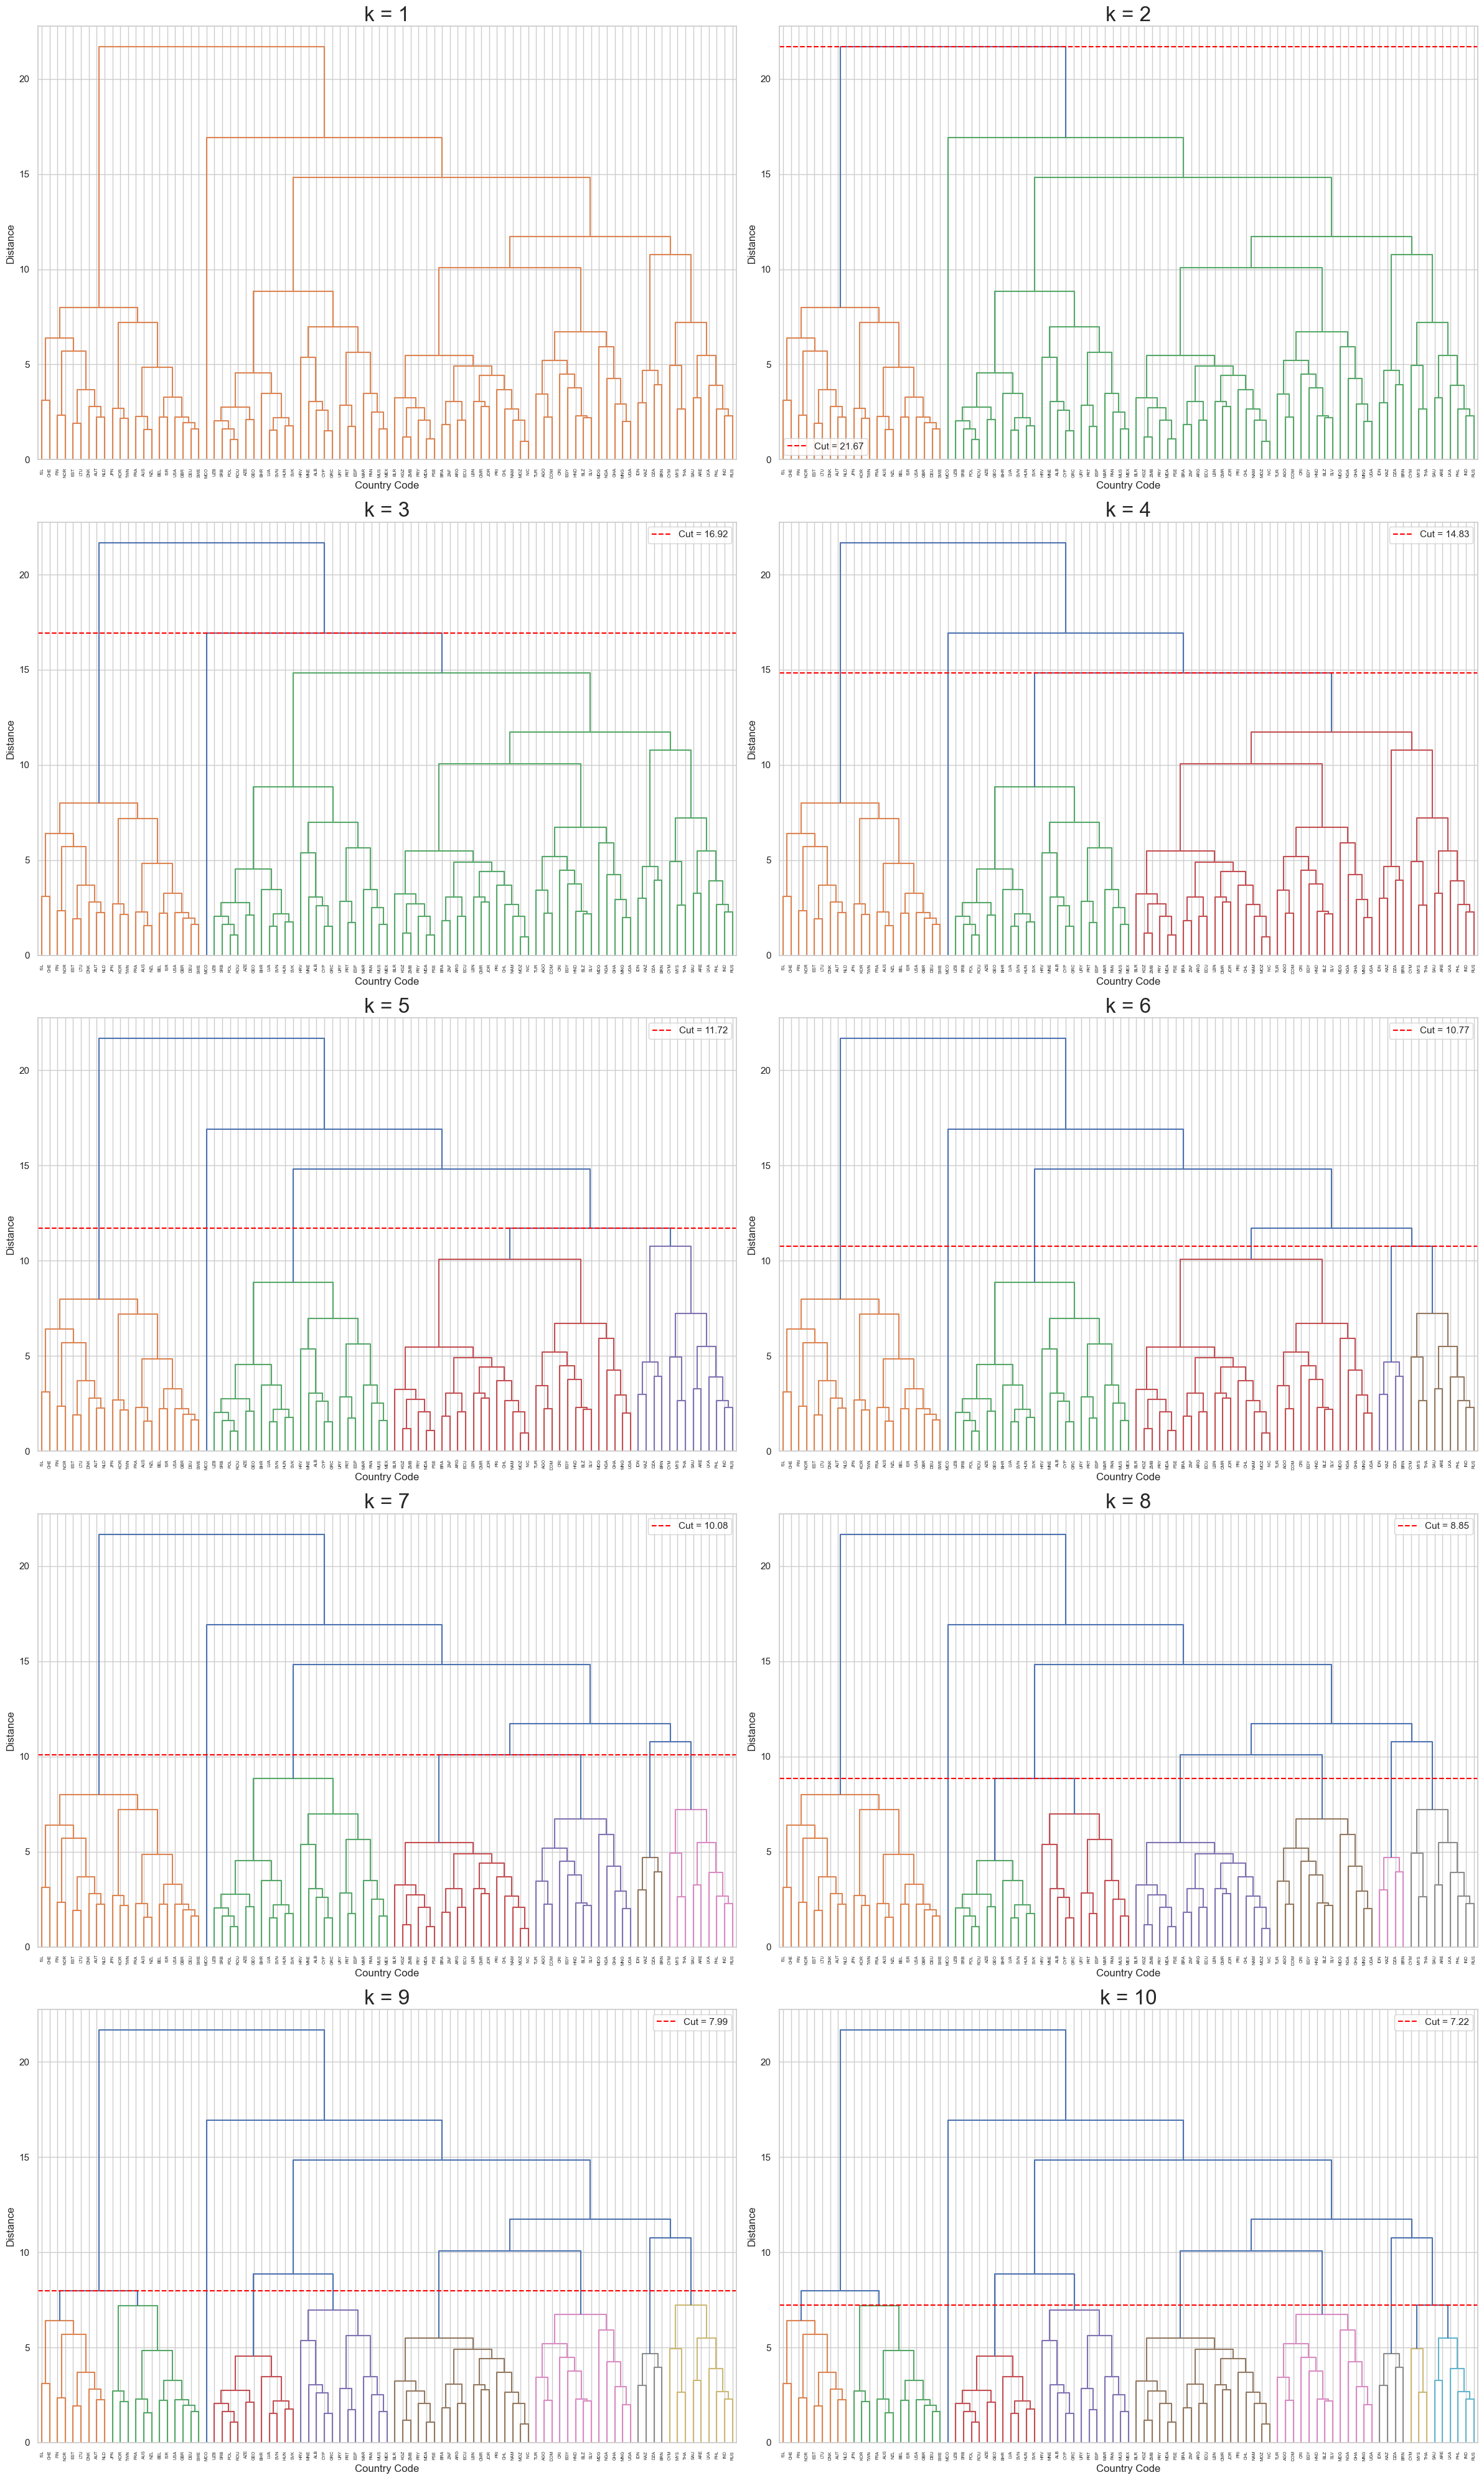

In [67]:
# Plot Silhouette and Elbow methods to aid in choosing the number of clusters
silhouette_scores = utils.plot_silhouette_scores(numerical_features_feature_selection_df, k_range=range(2, 11))
inertias = utils.plot_elbow_method(numerical_features_feature_selection_df, k_range=range(1, 11))

# Plot multiple dendrograms for k = 1 to 10 to visually compare cluster separations
utils.plot_multiple_dendrograms(numerical_features_feature_selection_df, countries=labels_df, max_k=10)

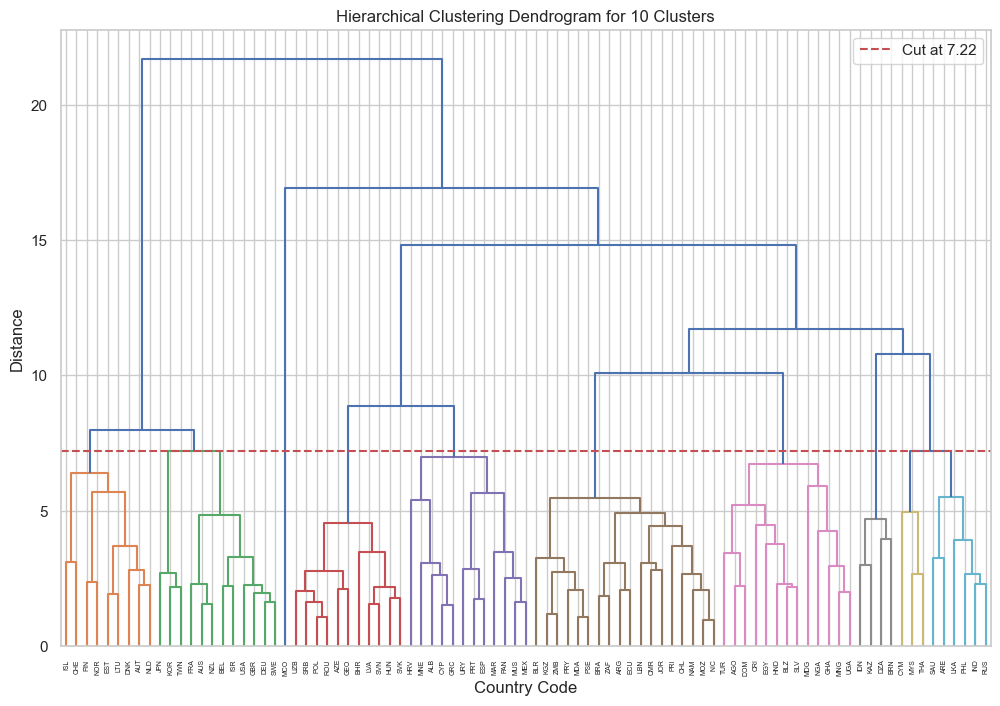

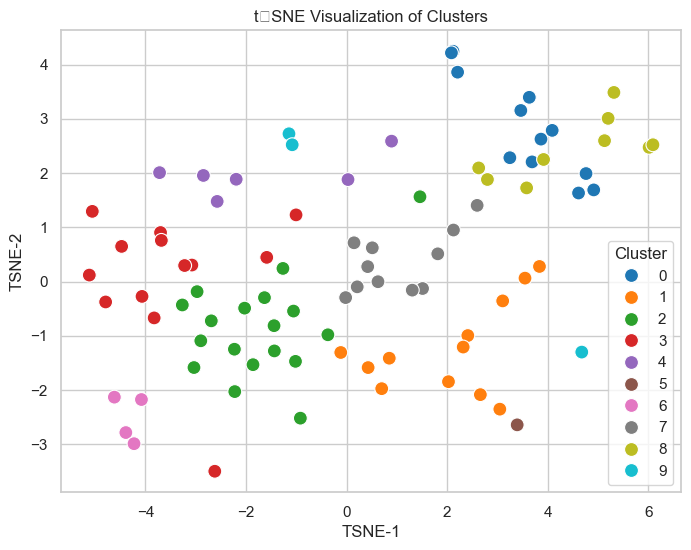

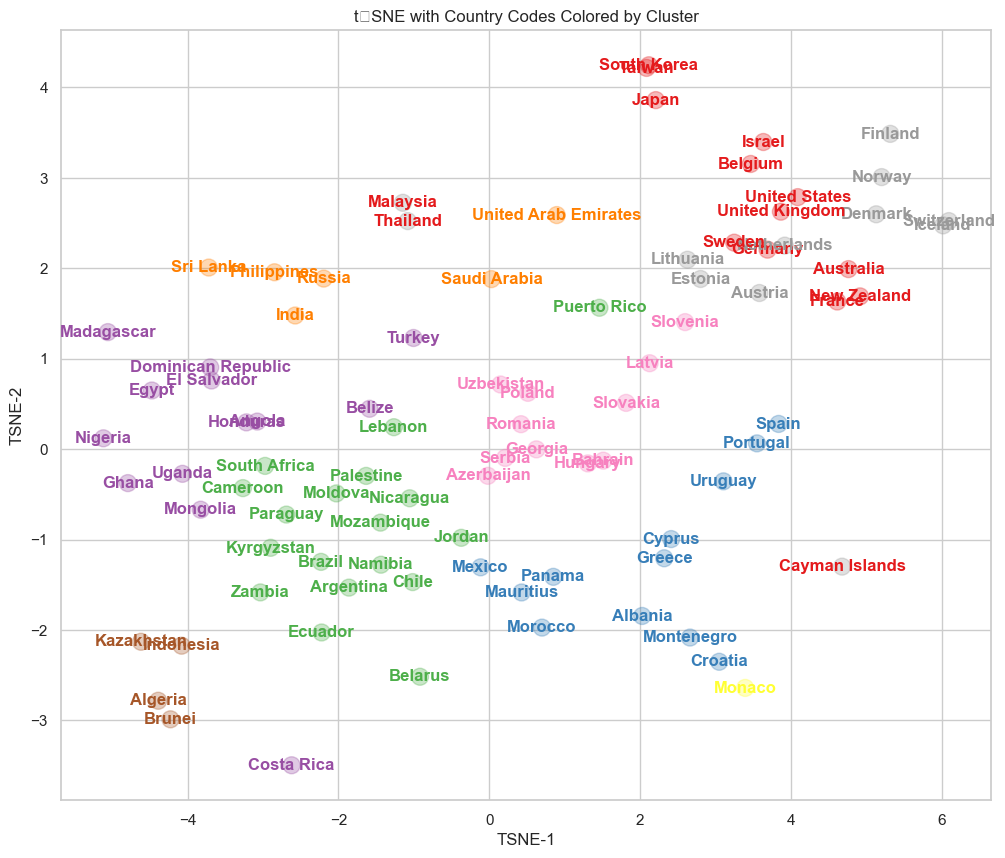

Validation Indices:
Davies-Bouldin Index: 1.4560041296303141
Calinski-Harabasz Index: 13.849196557890908
Dunn Index: 0.2422612654648754
Cluster mapping:
Cluster 0: Australia, Belgium, France, Germany, Israel, Japan, New Zealand, South Korea, Sweden, Taiwan, United Kingdom, United States
Cluster 1: Albania, Croatia, Cyprus, Greece, Mauritius, Mexico, Montenegro, Morocco, Panama, Portugal, Spain, Uruguay
Cluster 2: Argentina, Belarus, Brazil, Cameroon, Chile, Ecuador, Jordan, Kyrgyzstan, Lebanon, Moldova, Mozambique, Namibia, Nicaragua, Palestine, Paraguay, Puerto Rico, South Africa, Zambia
Cluster 3: Angola, Belize, Costa Rica, Dominican Republic, Egypt, El Salvador, Ghana, Honduras, Madagascar, Mongolia, Nigeria, Turkey, Uganda
Cluster 4: India, Philippines, Russia, Saudi Arabia, Sri Lanka, United Arab Emirates
Cluster 5: Monaco
Cluster 6: Algeria, Brunei, Indonesia, Kazakhstan
Cluster 7: Azerbaijan, Bahrain, Georgia, Hungary, Latvia, Poland, Romania, Serbia, Slovakia, Slovenia, Uzbeki

In [68]:
k_opt = 10
# Perform hierarchical clustering on the selected features using a chosen k
df_combined, cluster_labels, hierarchical_indices = utils.run_clustering_analysis(
    numerical_features_feature_selection_df,
    countries=labels_df,
    k_clusters=k_opt,
    plot_dendrogram_flag=True,
    plot_tsne_flag=True,
    compute_validation=True
)

In [69]:
# Hierarchical Clustering results
hierarchical_row = pd.DataFrame([{
    "Dataset": "Optimized Dataset",
    "Algorithm": "Hierarchical Clustering",
    "Davies-Bouldin Index": hierarchical_indices["Davies-Bouldin Index"],
    "Calinski-Harabasz Index": hierarchical_indices["Calinski-Harabasz Index"],
    "Dunn Index": hierarchical_indices["Dunn Index"]
}])

# Append Hierarchical Clustering row
results_df = pd.concat([results_df, hierarchical_row], ignore_index=True)

results_df.head()

,Dataset,Algorithm,Davies-Bouldin Index,Calinski-Harabasz Index,Dunn Index
0,Baseline Dataset,K-means,1.514415,31.893142,0.078433
1,Baseline Dataset,Hierarchical Clustering,1.245876,18.026237,0.250485
2,Optimized Dataset,K-means,1.394831,20.864151,0.149257
3,Optimized Dataset,Hierarchical Clustering,1.456004,13.849197,0.242261


## Final result comparison
- **Davies-Bouldin Index** (lower is better)
- **Calinski-Harabasz Index** (higher is better)
- **Dunn Index** (higher is better)

In [70]:
results_df.head()

,Dataset,Algorithm,Davies-Bouldin Index,Calinski-Harabasz Index,Dunn Index
0,Baseline Dataset,K-means,1.514415,31.893142,0.078433
1,Baseline Dataset,Hierarchical Clustering,1.245876,18.026237,0.250485
2,Optimized Dataset,K-means,1.394831,20.864151,0.149257
3,Optimized Dataset,Hierarchical Clustering,1.456004,13.849197,0.242261


## Conclusions

### SWOT Analysis

**Strengths** : 

Comprehensive data exploration: The approach starts with thorough EDA, understanding missing data, distributions, and feature relationships. 
Multi-step data cleaning and feature handling: From imputation to scaling,  systematically prepared data for clustering. 
Statistical rigor: Incorporating correlation heatmaps, permutation tests, and rank-based comparisons adds validity to the insights. 
Use of multiple clustering techniques: K-Means, Agglomerative Clustering, and DBSCAN provide multiple lenses to identify patterns, ensuring no single algorithm biases the results. 
Visualization-driven approach: The methodology prioritizes visual validation (e.g., PCA, t-SNE, dendrograms) to confirm and interpret cluster separation. 

  
**Weaknesses** : 

Small dataset: With only 89 entries, the statistical power is limited, making clusters more susceptible to noise. 
Potential overinterpretation of clusters: Clustering is an unsupervised technique; interpreting clusters as “truth” without domain knowledge context can be misleading. 
Limited real-world profiling of clusters: The methodology clusters the data well, but does not interpret clusters in the broader context (e.g., economic factors, regional stability). 

 
**Opportunities** : 

Expand the data: More data or additional features (e.g., economic, cultural, political data) would provide a richer basis for clustering. 
Test multiple imputation strategies: Try simpler imputation (mean/median) vs. MLE to see if cluster stability changes. 
Develop interpretive narratives: Create profiles of each cluster to explain what they represent, improving stakeholder understanding. 
Interactive presentation: Present the methodology interactively (dashboards) for dynamic interpretation and easier updates. 

**Threats**: 

Sensitivity of clustering algorithms: Clustering depends on distance measures and scaling. Small changes in preprocessing can change results significantly. 
Data quality risks: High missingness in some features may lead to misleading clusters even with sophisticated imputation. 
Potential for overfitting: Complex methodology on a small dataset can overfit patterns that don’t generalize. 
Static insights: Without dynamic updates, static methodology might become outdated as data changes.